# [LAB-06] 캡스톤 (1) - MPG 데이터셋 (ADsP 기출)

1. 각 문제의 질문을 읽고, **어떤 그래프가 답을 찾기에 적절한지 스스로 판단**하여 직접 시각화하세요.
2. 그래프를 보고 객관식 보기 중 정답을 고르세요.

## 준비작업

### 1. 라이브러리 참조

In [ ]:
from jussam import load_data
from helpers import *
from pandas import pivot_table
import numpy as np

c:\Users\ITWILL\workspace\캡스톤


### 2. 데이터셋 불러오기

In [2]:
origin = load_data("mpg")
origin.head()

📚 1999년과 2008년에 미국 EPA에서 조사하여 발표한 자동차 주요 모델별 연비 데이터 (출처: ADsP 기출 / R 내장 데이터)

    field         description
--  ------------  -------------------------------------------------------------
 0  manufacturer  자동차 제조사 (문자열)
 1  model         자동차 모델명 (문자열)
 2  displ         자동차 배기량 (연속형)
 3  year          제조년도 (연속형)
 4  cyl           엔진 실린더 수 (범주형)
 5  trans         자동차 트랜스미션 종류 (범주형)
 6  drv           자동차 구동 방식 (범주형). f=전륜구동, r=후륜구동, 4=사륜구동
 7  cty           도심 연비 (마일/갤론)
 8  hwy           고속도로 연비 (마일/갤론)
 9  fl            연료 종류 (범주형)
10  class         자동차 분류 (범주형)



,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
id,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),f,18,29,p,compact
2,audi,a4,1.800,1999,4,manual(m5),f,21,29,p,compact
3,audi,a4,2.000,2008,4,manual(m6),f,20,31,p,compact
4,audi,a4,2.000,2008,4,auto(av),f,21,30,p,compact
5,audi,a4,2.800,1999,6,auto(l5),f,16,26,p,compact


### 3. 데이터 전처리

- 구동방식 컬럼 값을 이해하기 쉬운 값으로 변환

In [3]:
df = origin.copy()
df["drv"] = df["drv"].map({"f": "전륜구동", "r": "후륜구동", "4": "4륜구동"})
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
id,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),전륜구동,18,29,p,compact
2,audi,a4,1.800,1999,4,manual(m5),전륜구동,21,29,p,compact
3,audi,a4,2.000,2008,4,manual(m6),전륜구동,20,31,p,compact
4,audi,a4,2.000,2008,4,auto(av),전륜구동,21,30,p,compact
5,audi,a4,2.800,1999,6,auto(l5),전륜구동,16,26,p,compact


## 문제 1. 출시 차량 수가 가장 많은 제조사는?

① audi  ② dodge  ③ toyota  ④ volkswagen

> 💡 **힌트**: 막대그래프 (제조사별 빈도)

## 정답
#### dodge가 제일 많이 출시됐고, toyota, volkswagen이 뒤를 잇는다. (정답: ② dodge)


In [4]:
freq = df.groupby("manufacturer").size().sort_values(ascending=False)
freq.head()

manufacturer
dodge         37
toyota        34
volkswagen    27
ford          25
chevrolet     19
dtype: int64

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Failed to find font weight 500, now using 400.
C:\Users\ITWILL\

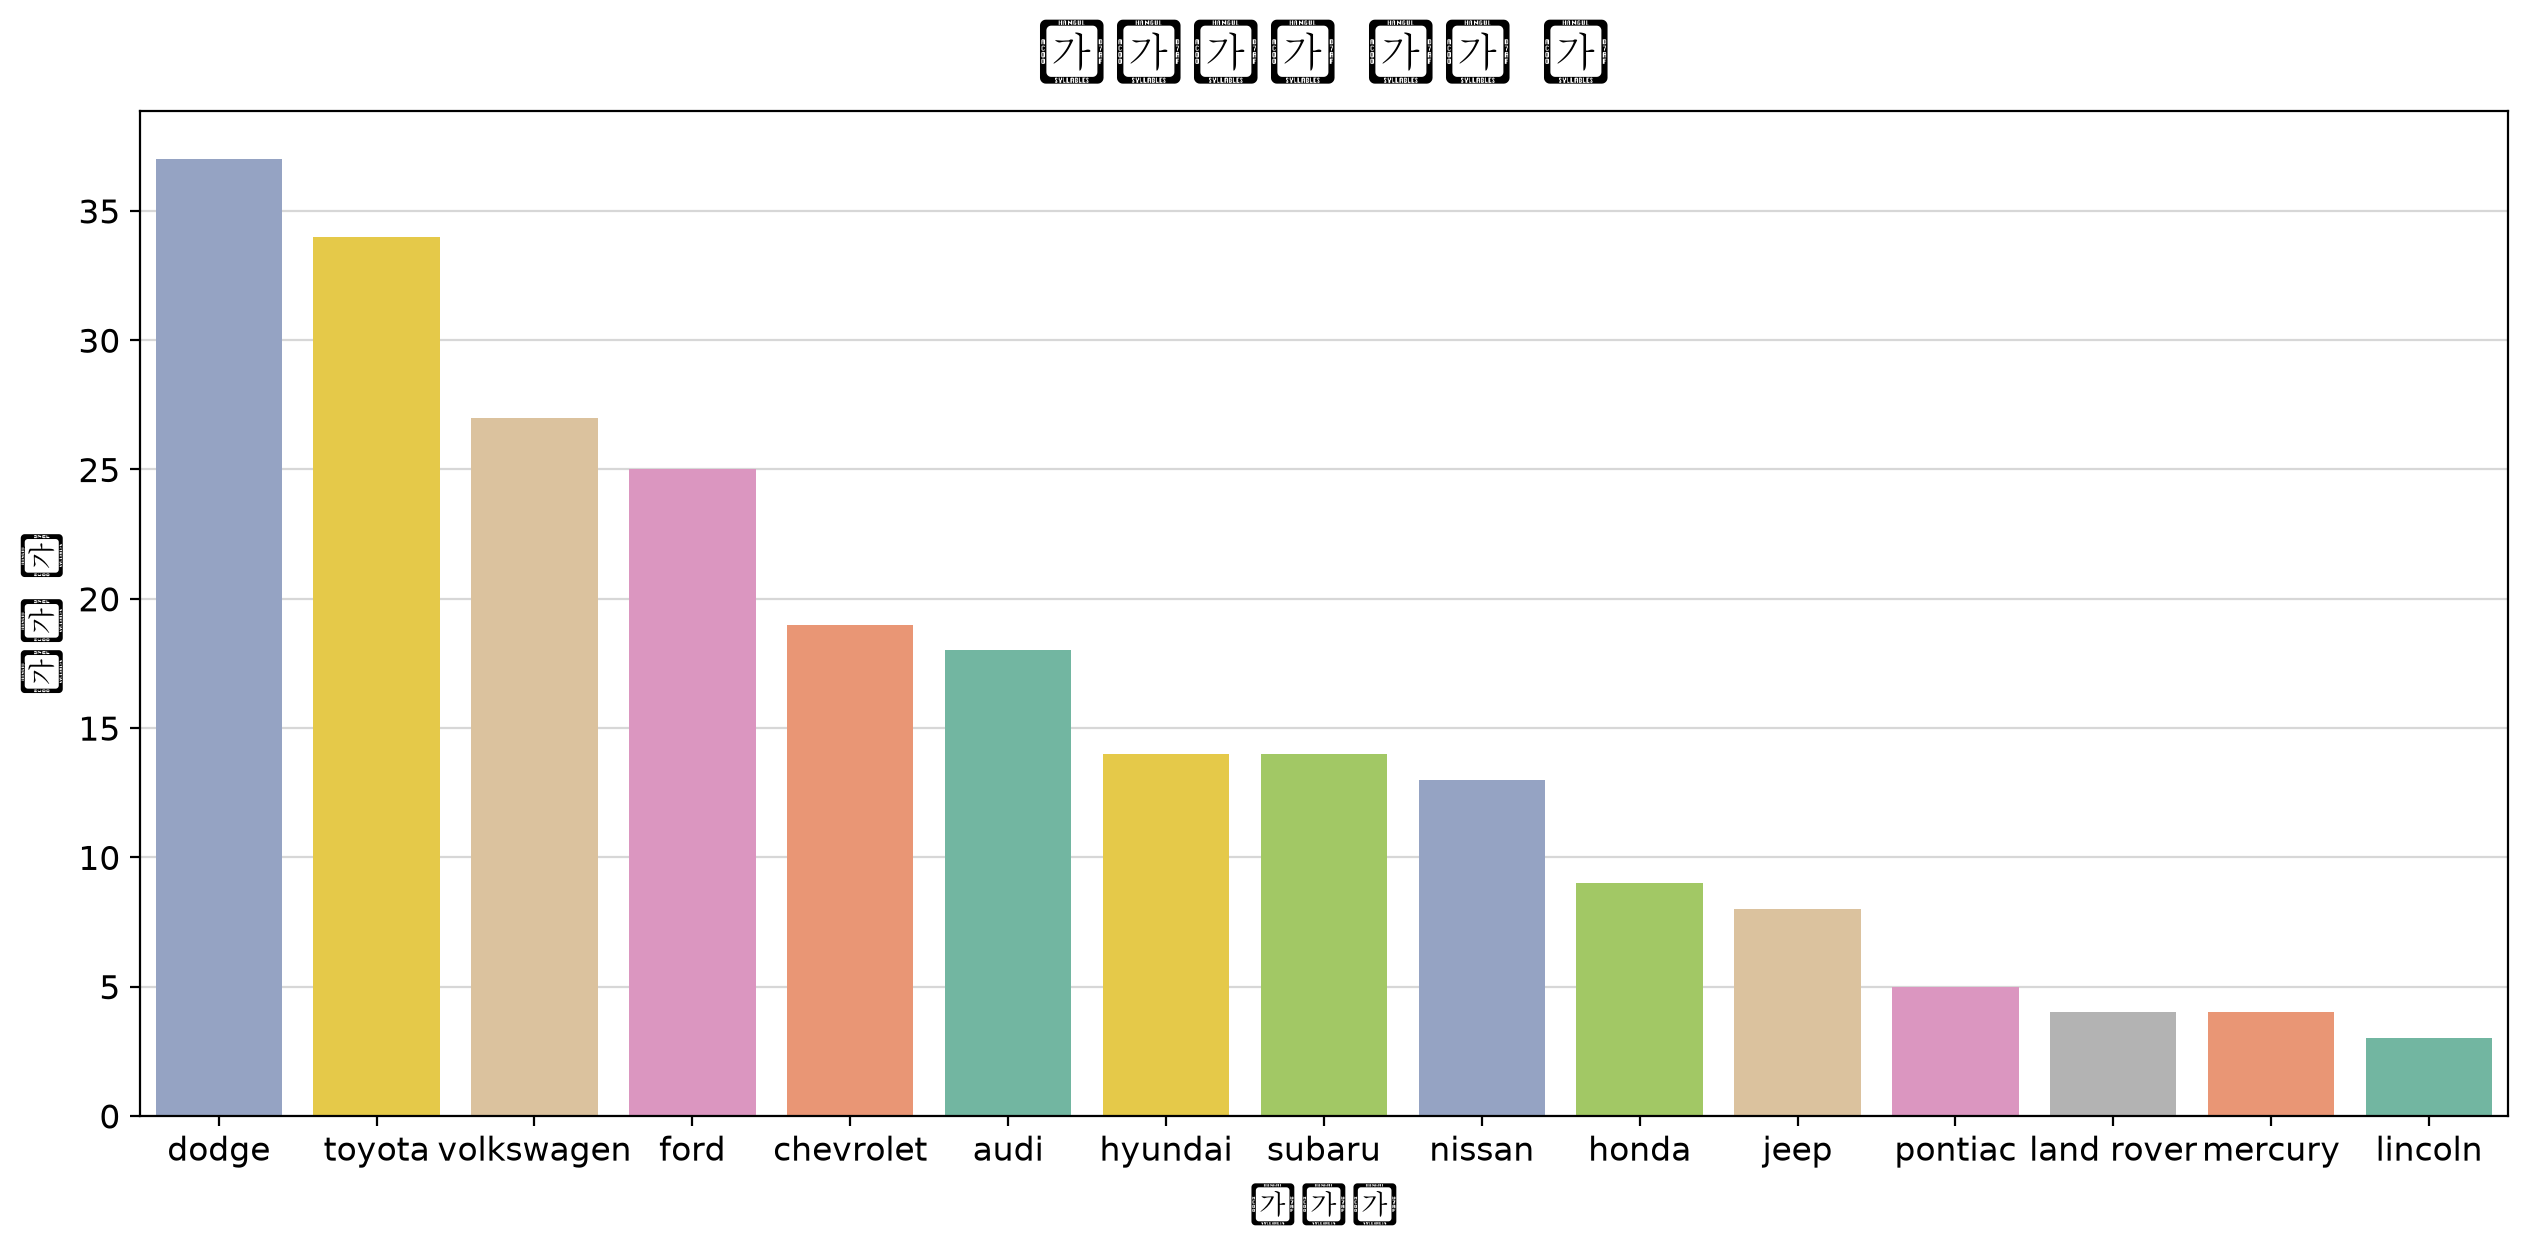

In [5]:
my_plot.countplot(df, x="manufacturer", order=freq.index,
                hue="manufacturer", palette="Set2",
                title="제조사별 차량 수", xlabel="제조사", ylabel="차량 수")

## 문제 2. 차종(`class`) 중 가장 많은 비중을 차지하는 종류는?

① compact  ② midsize  ③ suv  ④ pickup

> 💡 **힌트**: 막대그래프 또는 원그래프 (차종별 빈도)

## 정답
#### suv 차종이 압도적으로 비중이 크다. (정답: ③ suv)


In [6]:
cnt = df.groupby("class").size().sort_values(ascending=False)
cnt

class
suv           62
compact       47
midsize       41
subcompact    35
pickup        33
minivan       11
2seater        5
dtype: int64

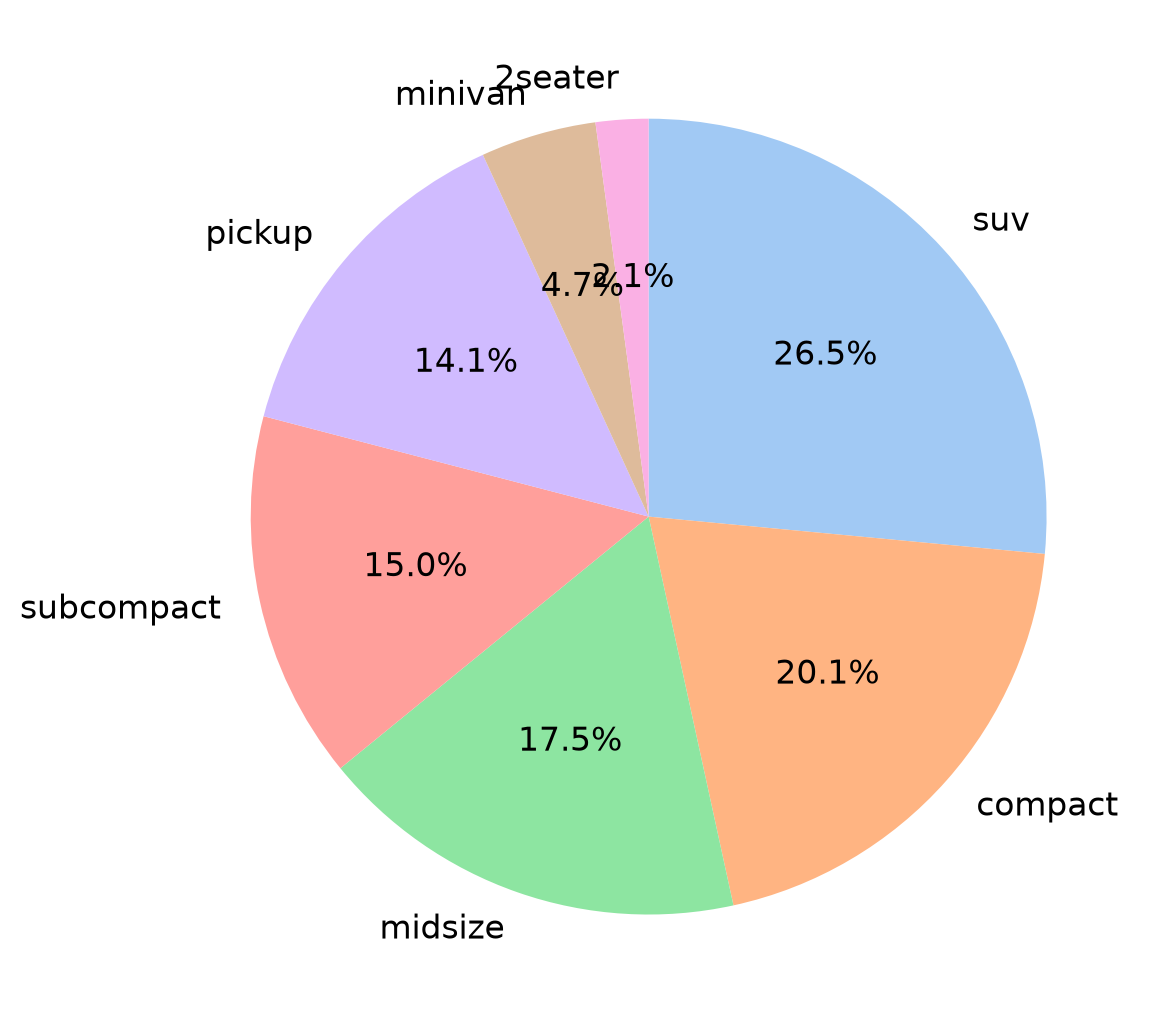

In [7]:
my_plot.pieplot(x=cnt.values, labels=cnt.index, palette="pastel", width=600, height=600)

## 문제 3. 구동방식(`drv`) 중 차량 수가 가장 적은 방식은?

① 전륜구동  ② 4륜구동  ③ 후륜구동  ④ 모두 동일

> 💡 **힌트**: 막대그래프 (구동방식별 빈도)

## 정답
#### 후륜구동 차량 수가 제일 적다. (정답: ③ 후륜구동)


C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47452 (\N{HANGUL SYLLABLE RYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 

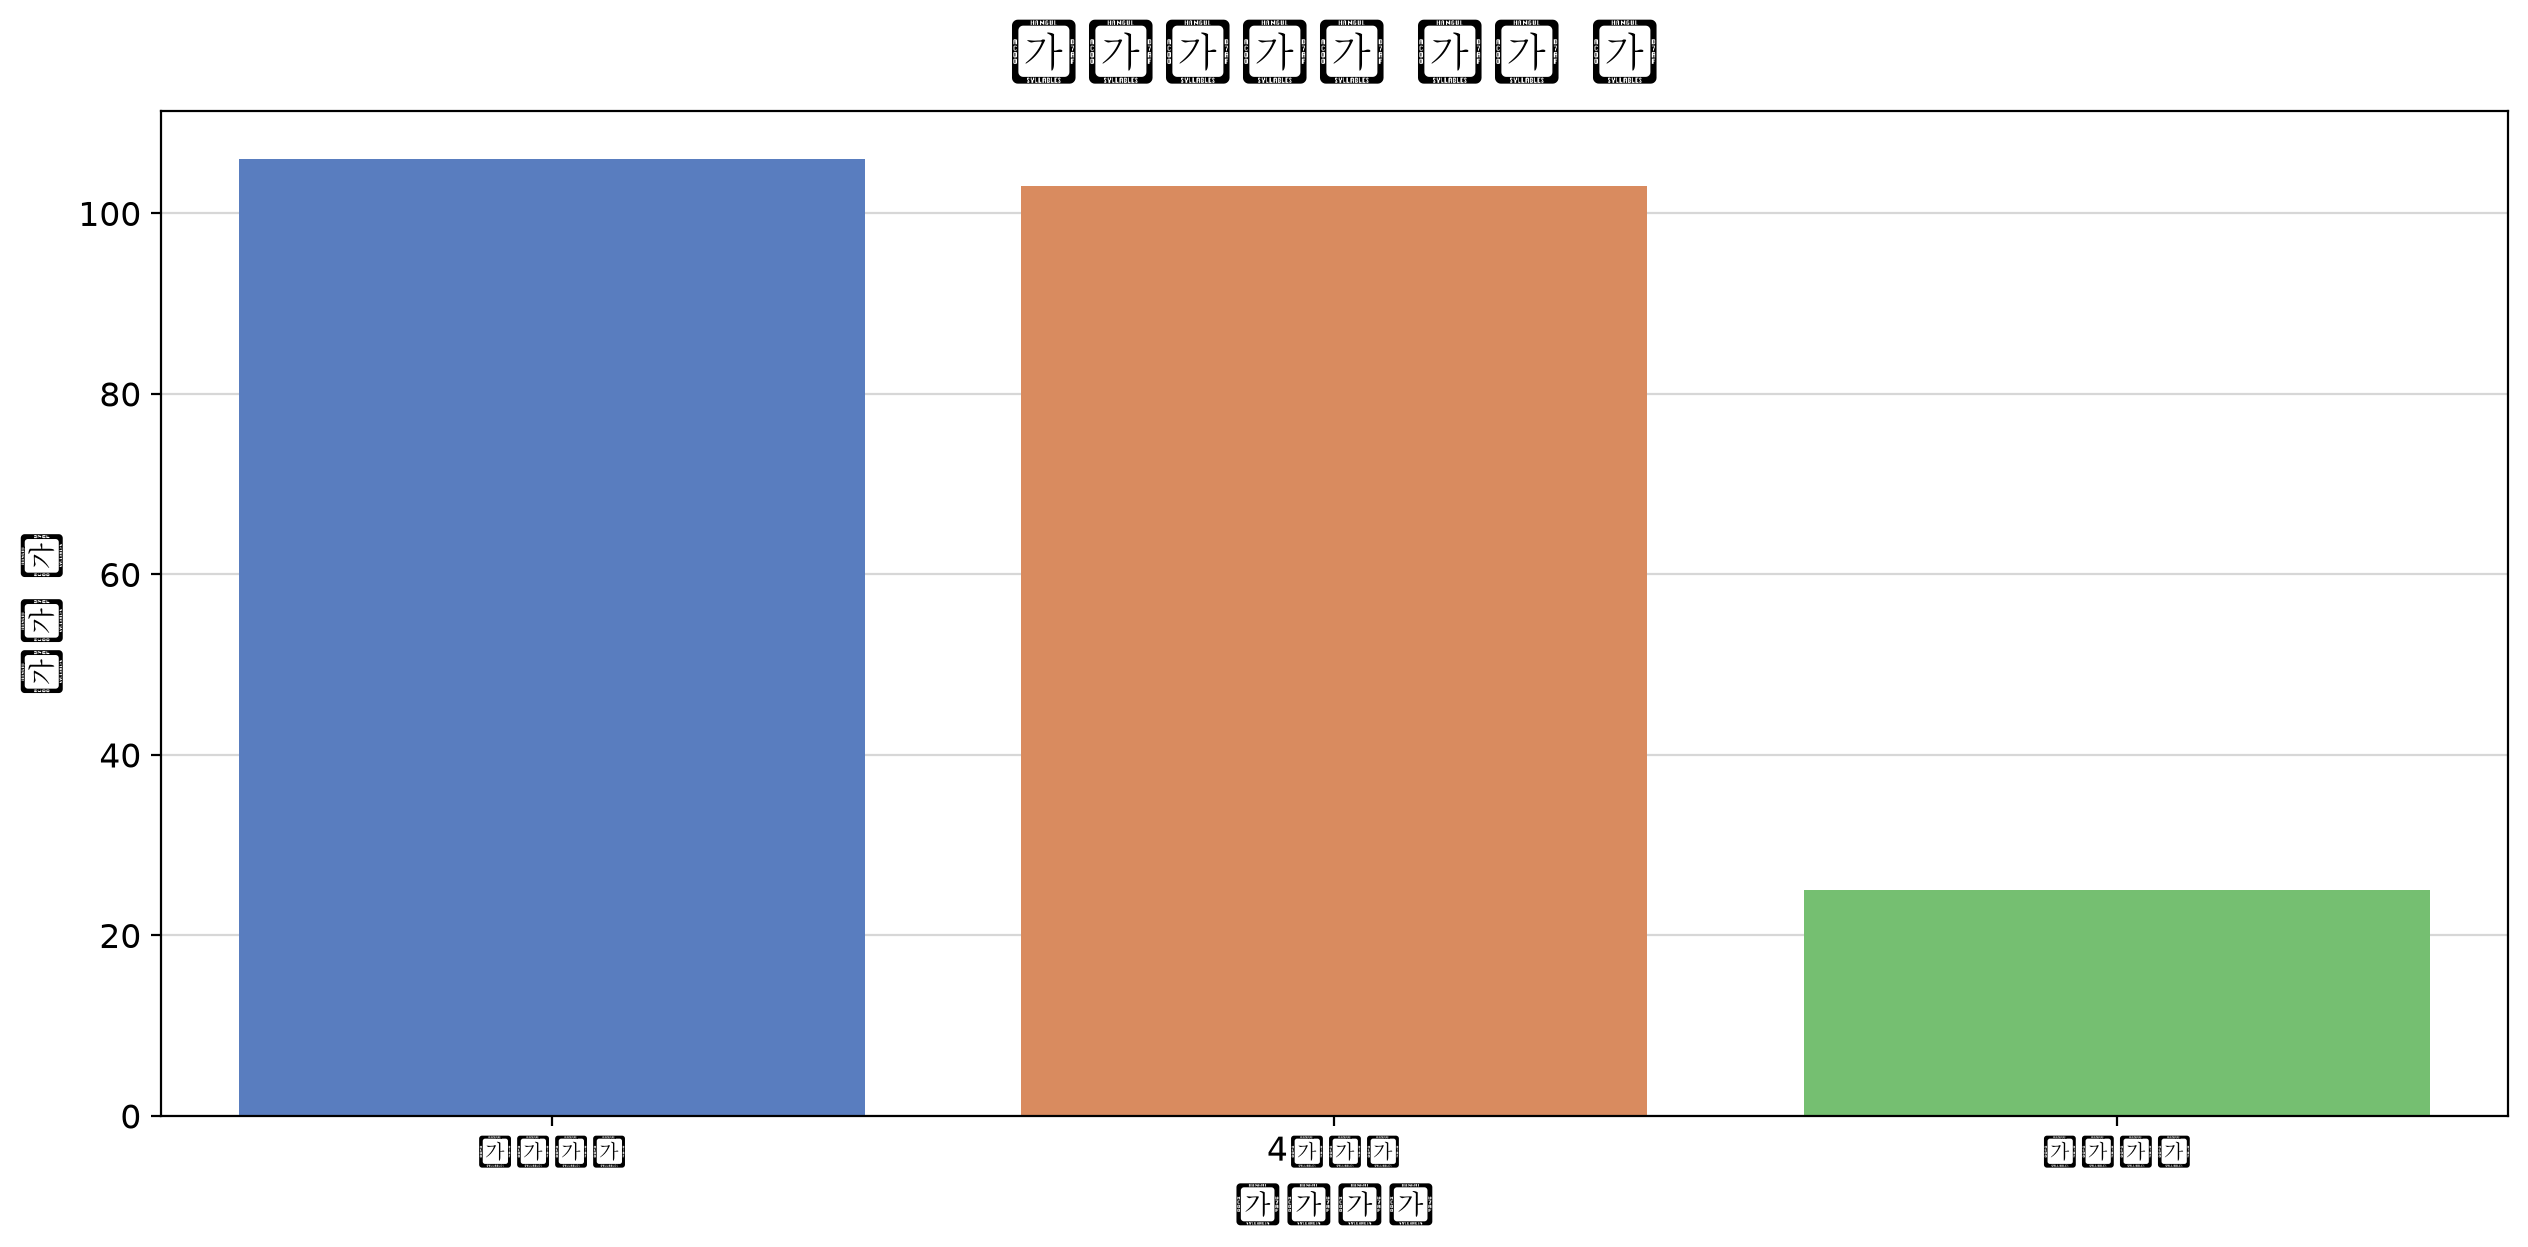

In [8]:
my_plot.countplot(df, x="drv", order=df["drv"].value_counts(ascending=False).index,
                hue="drv", palette="muted",
                title="구동방식별 차량 수", xlabel="구동방식", ylabel="차량 수")

## 문제 4. 도심 연비(`cty`) 평균이 가장 높은 구동방식은?

① 전륜구동  ② 4륜구동  ③ 후륜구동  ④ 모두 비슷

> 💡 **힌트**: 막대그래프 (구동방식별 cty 평균)

## 정답
#### 전륜구동이 도심 연비 평균이 제일 높다. (정답: ① 전륜구동)


In [9]:
cty_mean = df.groupby("drv")["cty"].mean().sort_values(ascending=False)
cty_mean

drv
전륜구동   19.972
4륜구동   14.330
후륜구동   14.080
Name: cty, dtype: float64

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47452 (\N{HANGUL SYLLABLE RYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 

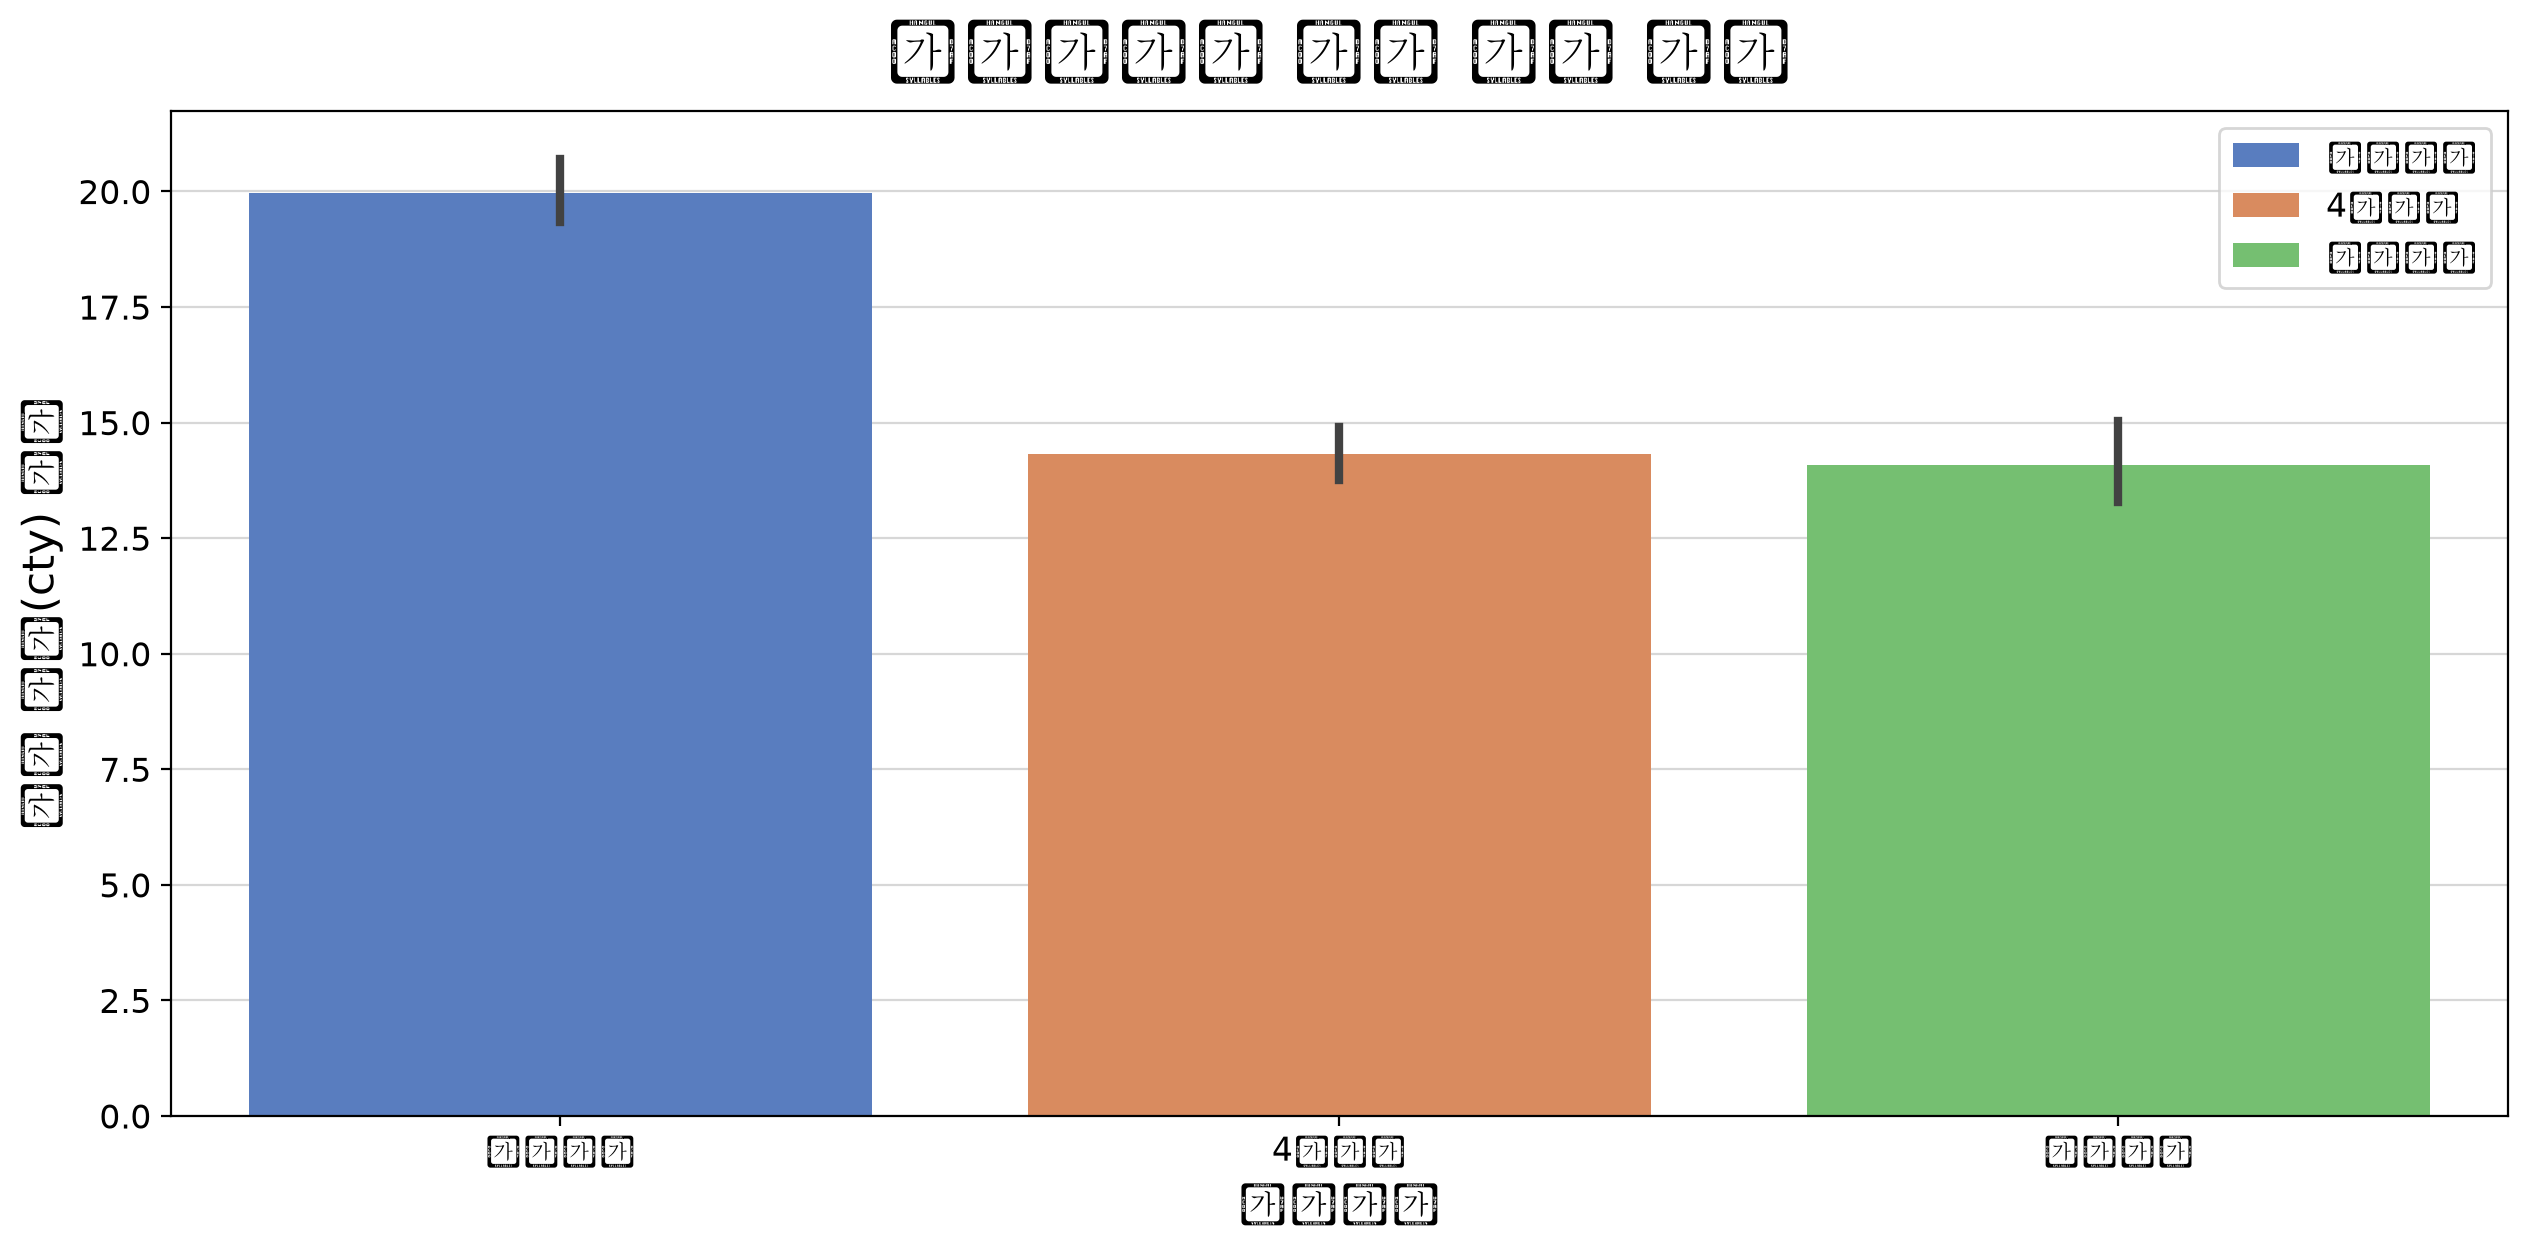

In [10]:
my_plot.barplot(df, x="drv", y="cty", estimator=np.mean,
                order=cty_mean.index, hue="drv", palette="muted",
                title="구동방식별 도심 연비 평균", xlabel="구동방식", ylabel="도심 연비(cty) 평균")

## 문제 5. 실린더 수(`cyl`)가 많아질수록 고속도로 연비(`hwy`)는 어떤 경향을 보이는가?

① 증가한다  ② 감소한다  ③ 관계가 없다  ④ U자 형태

> 💡 **힌트**: 막대그래프 (실린더 수별 hwy 평균)

## 정답
#### 실린더 수가 늘어날수록 고속도로 연비 평균은 대체로 낮아진다. (정답: ② 감소한다)


C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47536 (\N{HANGUL SYLLABLE RIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 4602

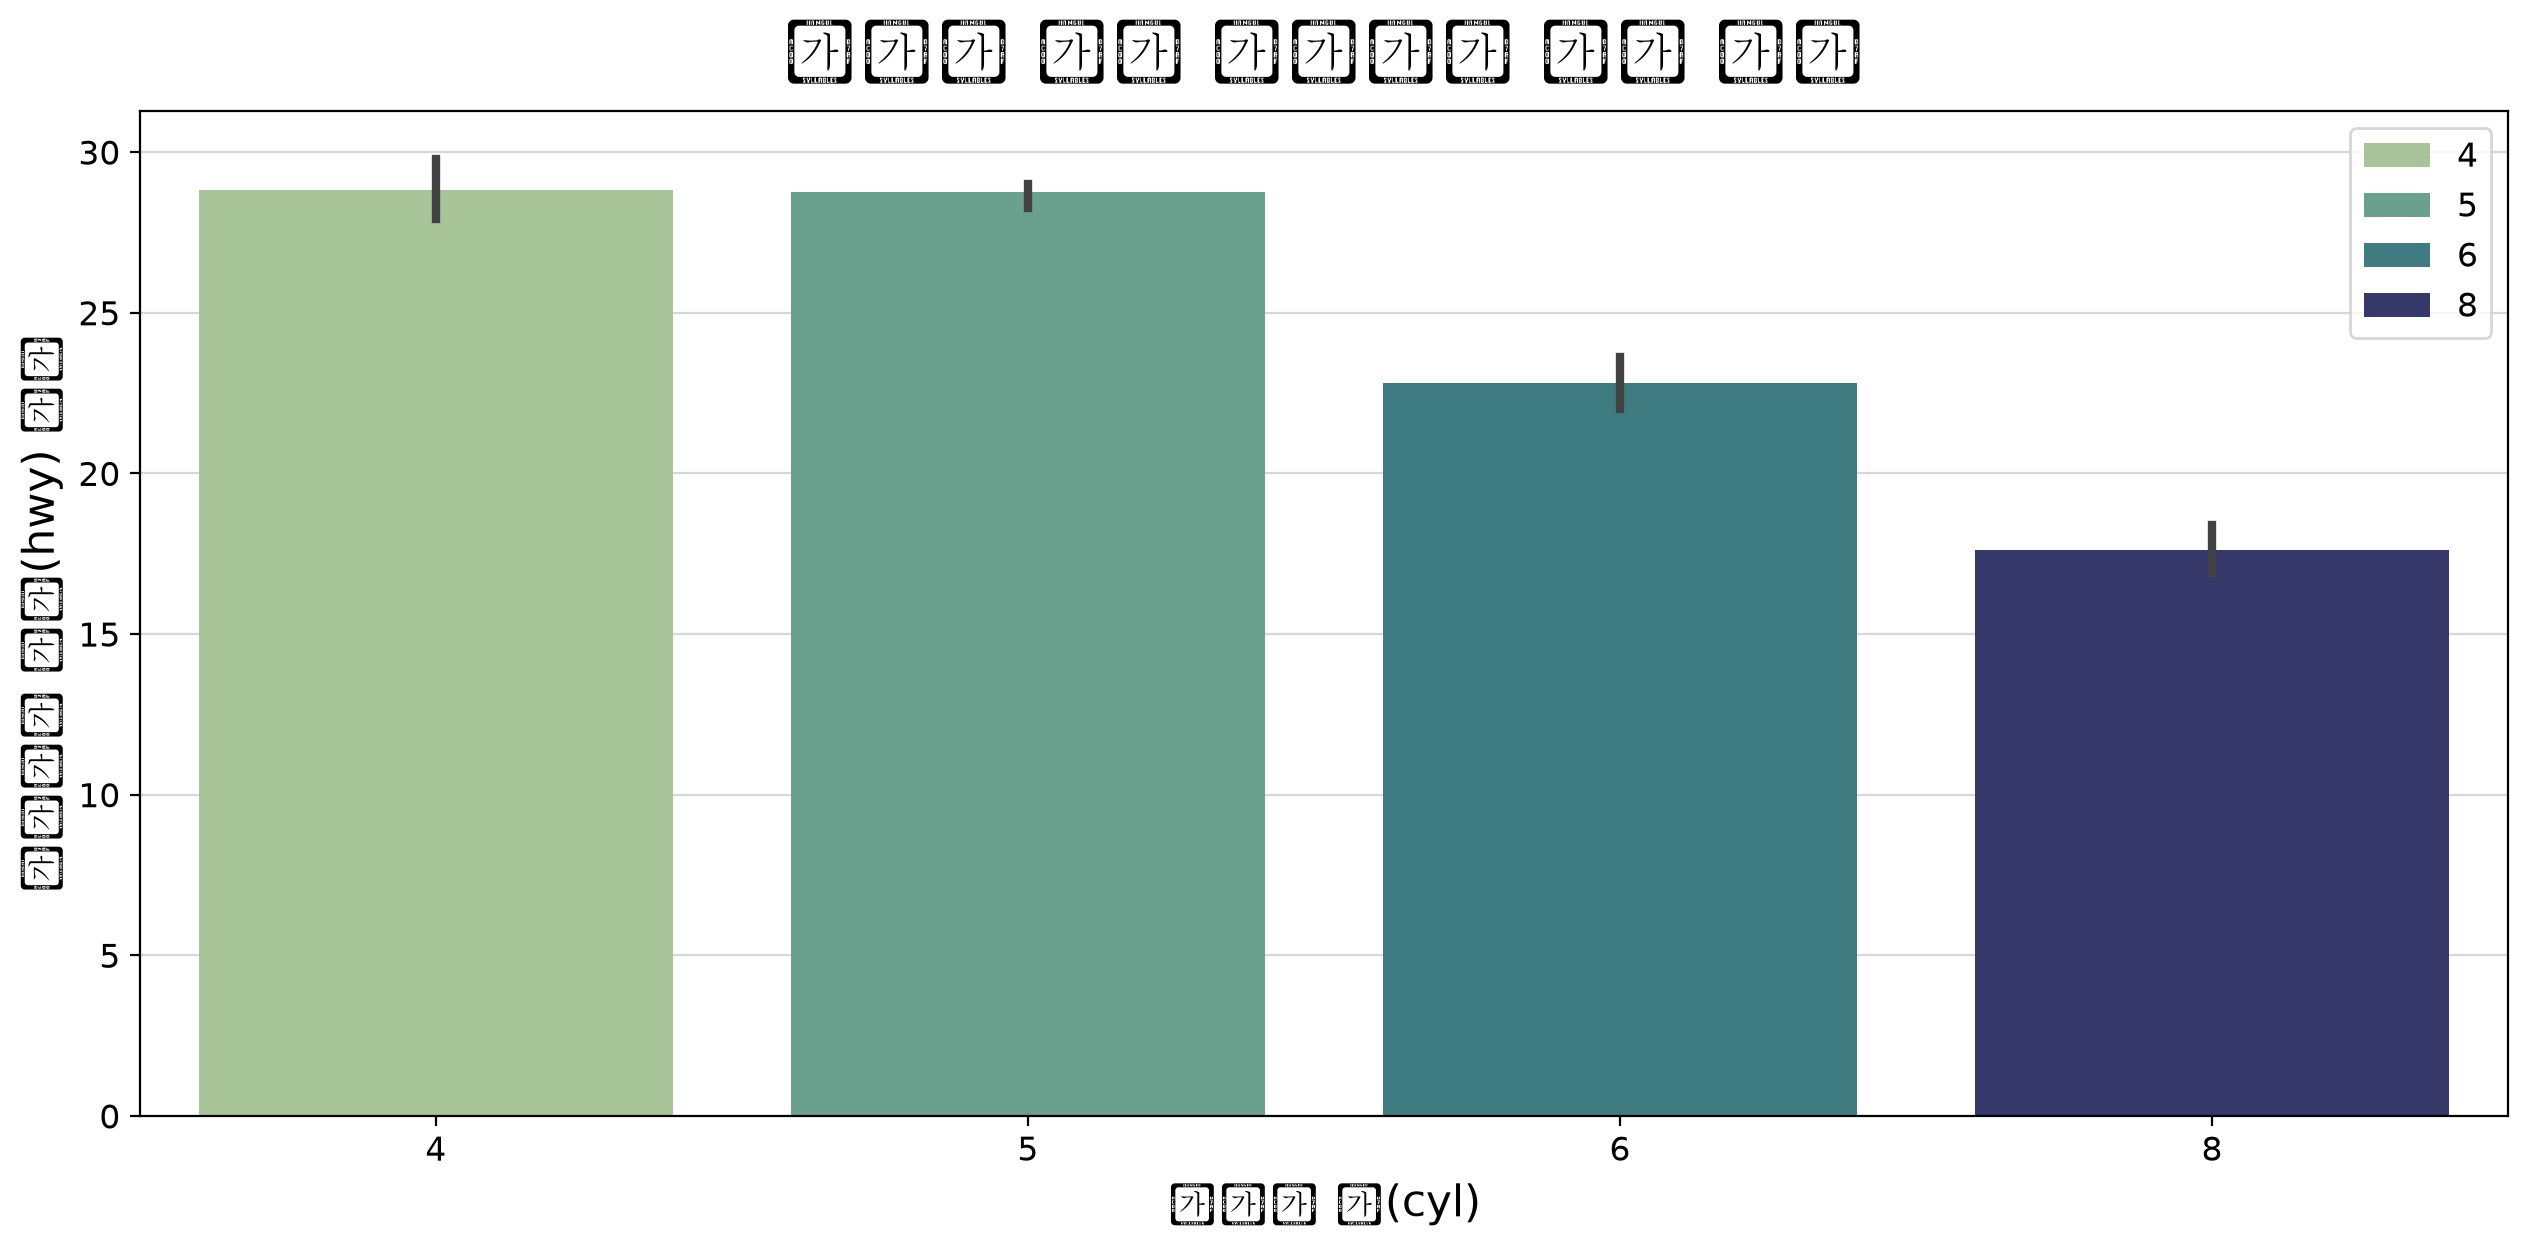

In [11]:
my_plot.barplot(df, x="cyl", y="hwy", estimator=np.mean,
                hue="cyl", palette="crest",
                title="실린더 수별 고속도로 연비 평균",
                xlabel="실린더 수(cyl)", ylabel="고속도로 연비(hwy) 평균")

## 문제 6. 배기량(`displ`)과 고속도로 연비(`hwy`)는 어떤 상관관계를 가지는가?

① 양(+)의 상관  ② 음(−)의 상관  ③ 상관 없음  ④ 곡선(2차) 관계

> 💡 **힌트**: 산점도 (+ 추세선)

## 정답
#### 배기량이 커질수록 고속도로 연비는 낮아지는 음의 상관관계를 보인다. (정답: ② 음(−)의 상관)


C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 471

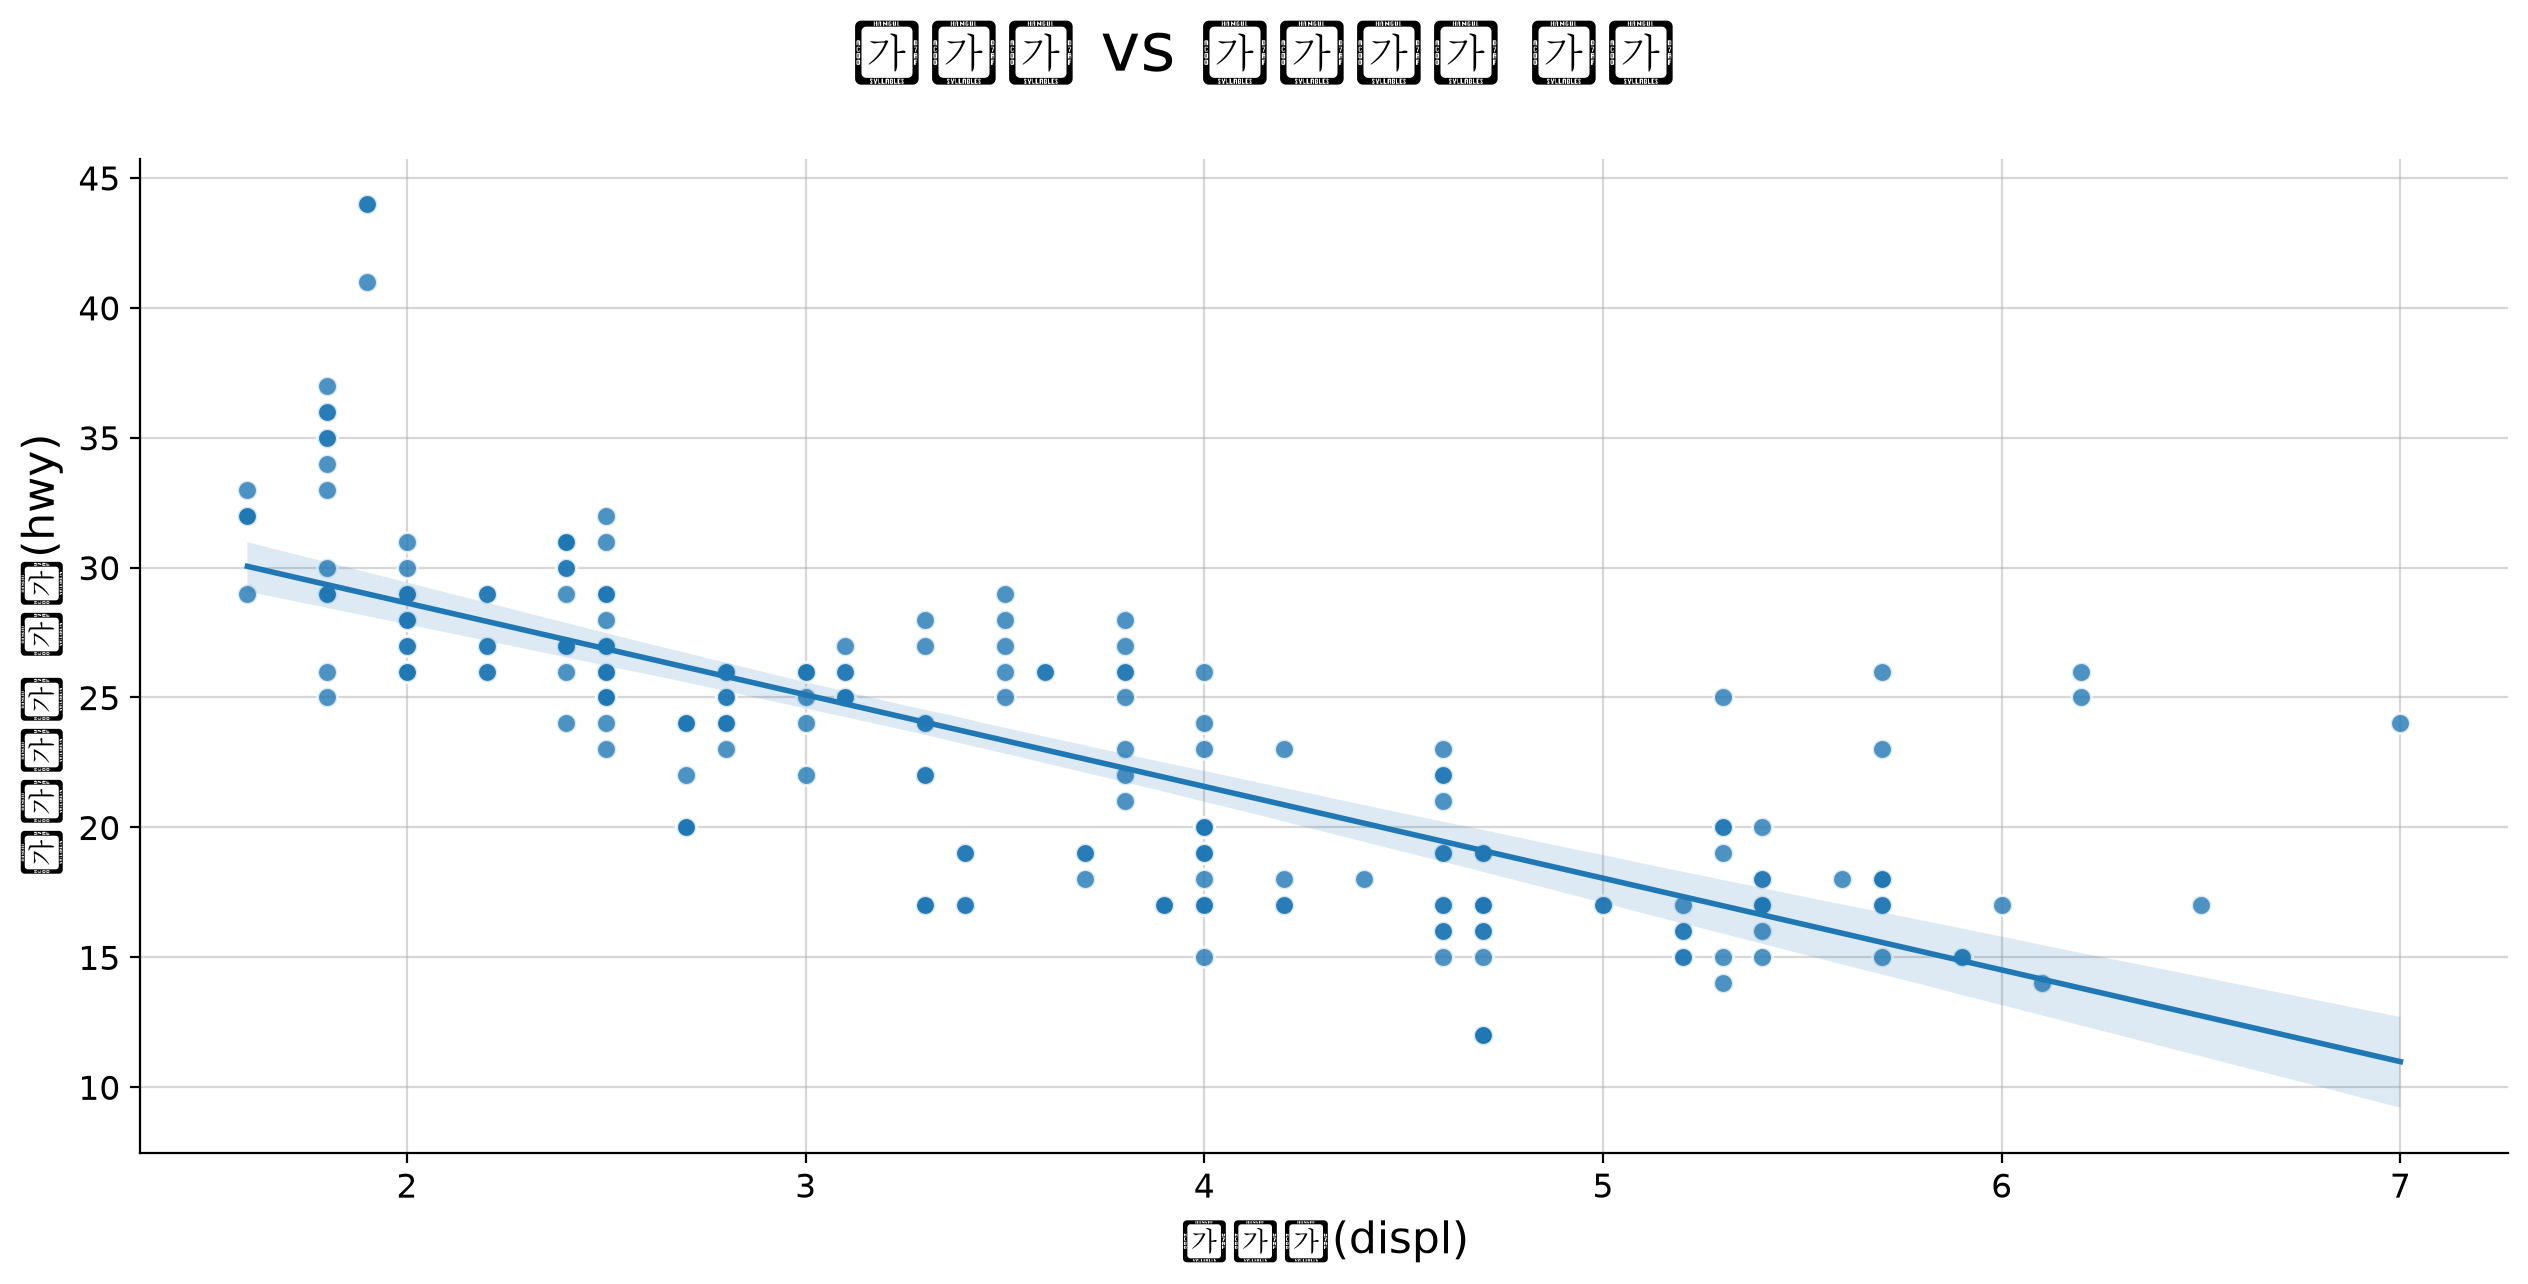

In [12]:
my_plot.lmplot(df, x="displ", y="hwy",
               title="배기량 vs 고속도로 연비", xlabel="배기량(displ)", ylabel="고속도로 연비(hwy)")

## 문제 7. 배기량(`displ`)과 더 강한(추세션의 기울기가 큰) 상관관계를 가지는 연비는?

① 도심 연비(cty)  ② 고속도로 연비(hwy)  ③ 둘이 완전히 동일  ④ 둘 다 상관 없음

> 💡 **힌트**: 산점도 2개를 비교 (+ 추세선)

## 정답
#### 두 산점도를 비교하면 hwy 쪽 추세선 기울기가 더 가파르다. (정답: ② 고속도로 연비(hwy))


C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ITWILL\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ITWILL\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ITWILL\AppData\Local\Programs\Python\Python312\Lib\site-pack

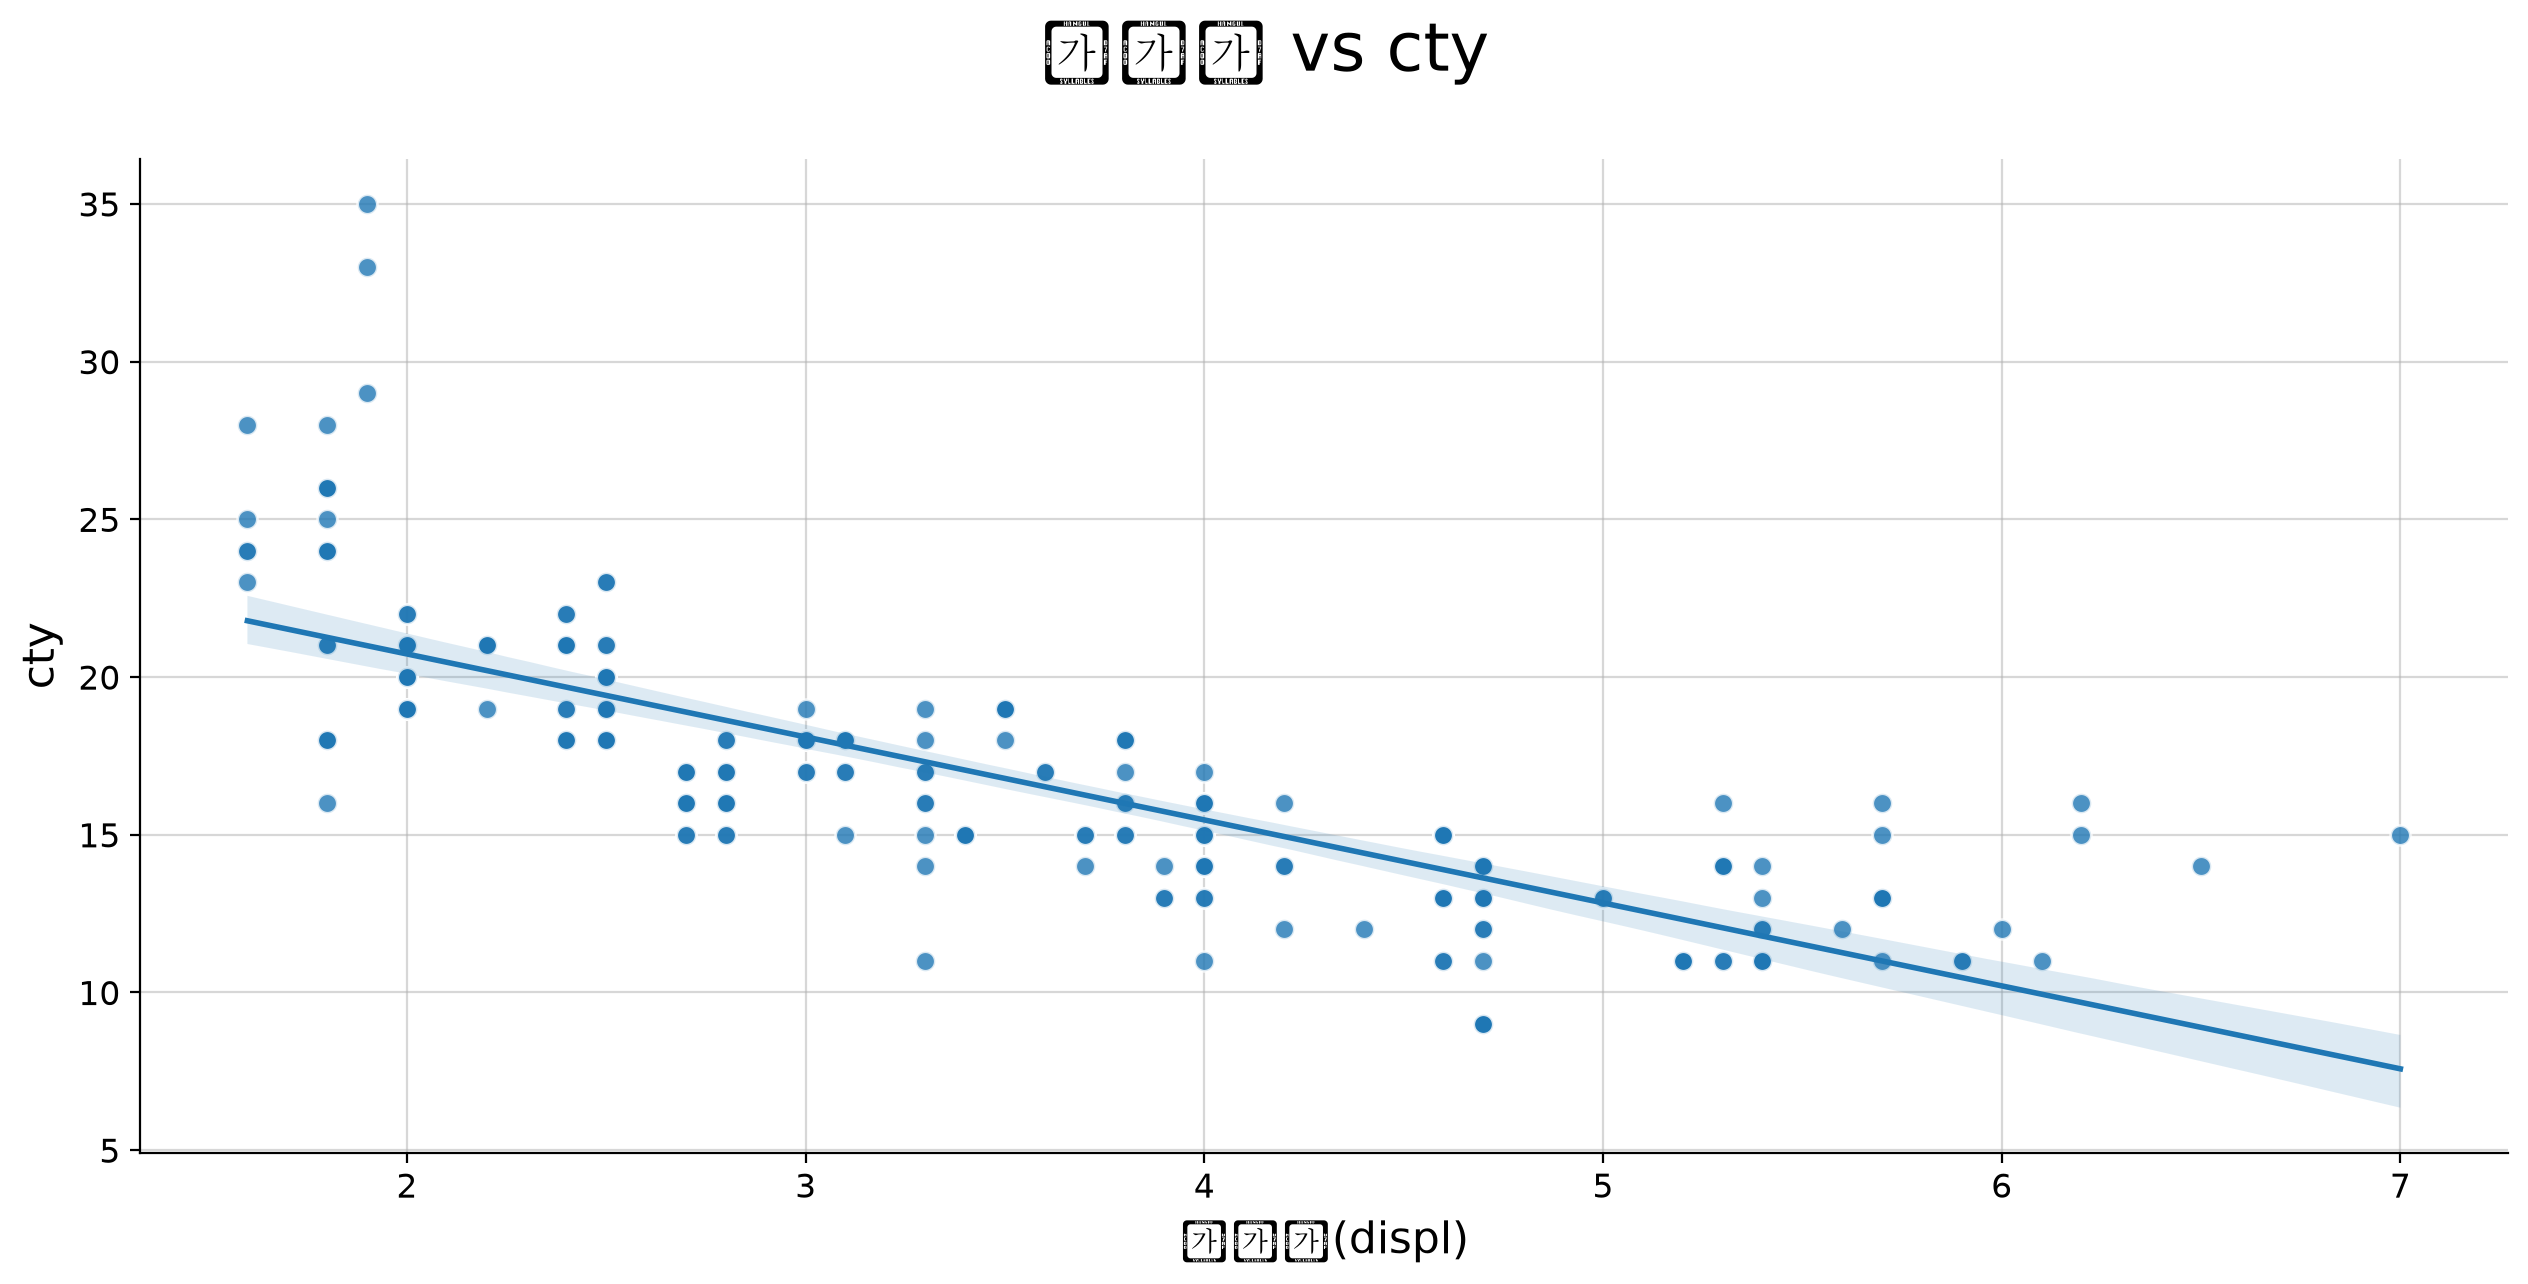

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ITWILL\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ITWILL\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ITWILL\AppData\Local\Programs\Python\Python312\Lib\site-pack

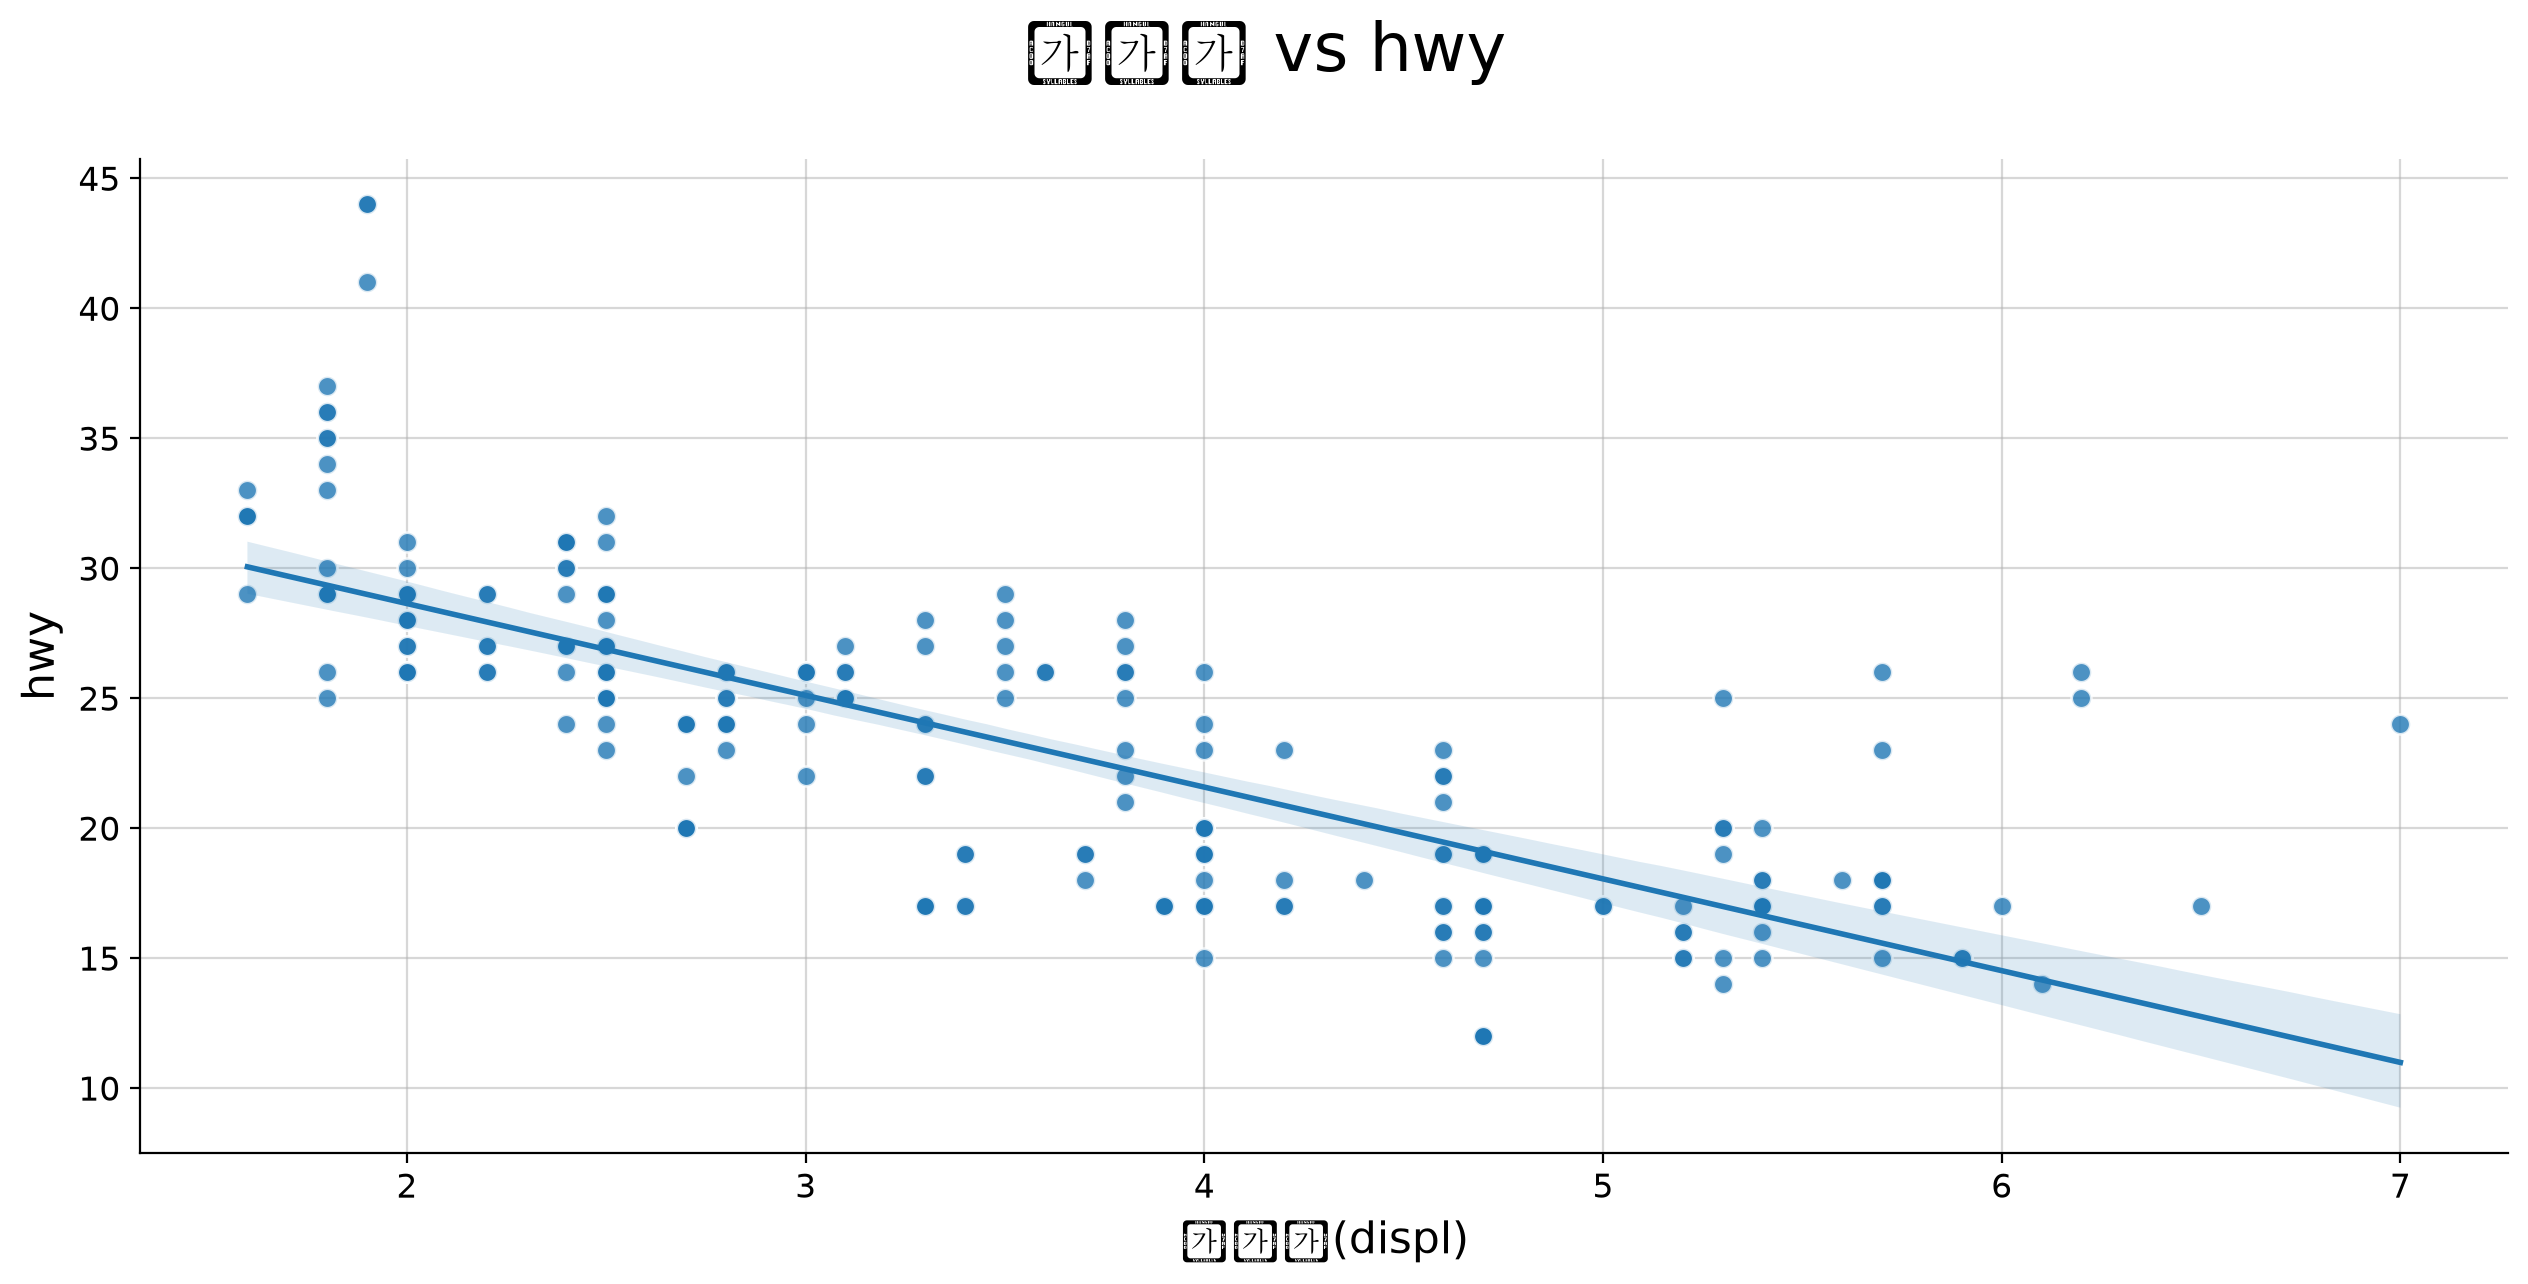

In [13]:
for target in ["cty", "hwy"]:
    my_plot.lmplot(df, x="displ", y=target,
                   title=f"배기량 vs {target}", xlabel="배기량(displ)", ylabel=target)

## 문제 8. 차종(`class`) 중 고속도로 연비(`hwy`) 평균이 가장 낮은 종류는?

① suv  ② pickup  ③ minivan  ④ midsize

> 💡 **힌트**: 막대그래프 (차종별 hwy 평균)

## 정답
#### pickup 차종의 고속도로 연비 평균이 제일 낮다. (정답: ② pickup)


In [14]:
hwy_mean = df.groupby("class")["hwy"].mean().sort_values()
hwy_mean

class
pickup       16.879
suv          18.129
minivan      22.364
2seater      24.800
midsize      27.293
subcompact   28.143
compact      28.298
Name: hwy, dtype: float64

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 50672

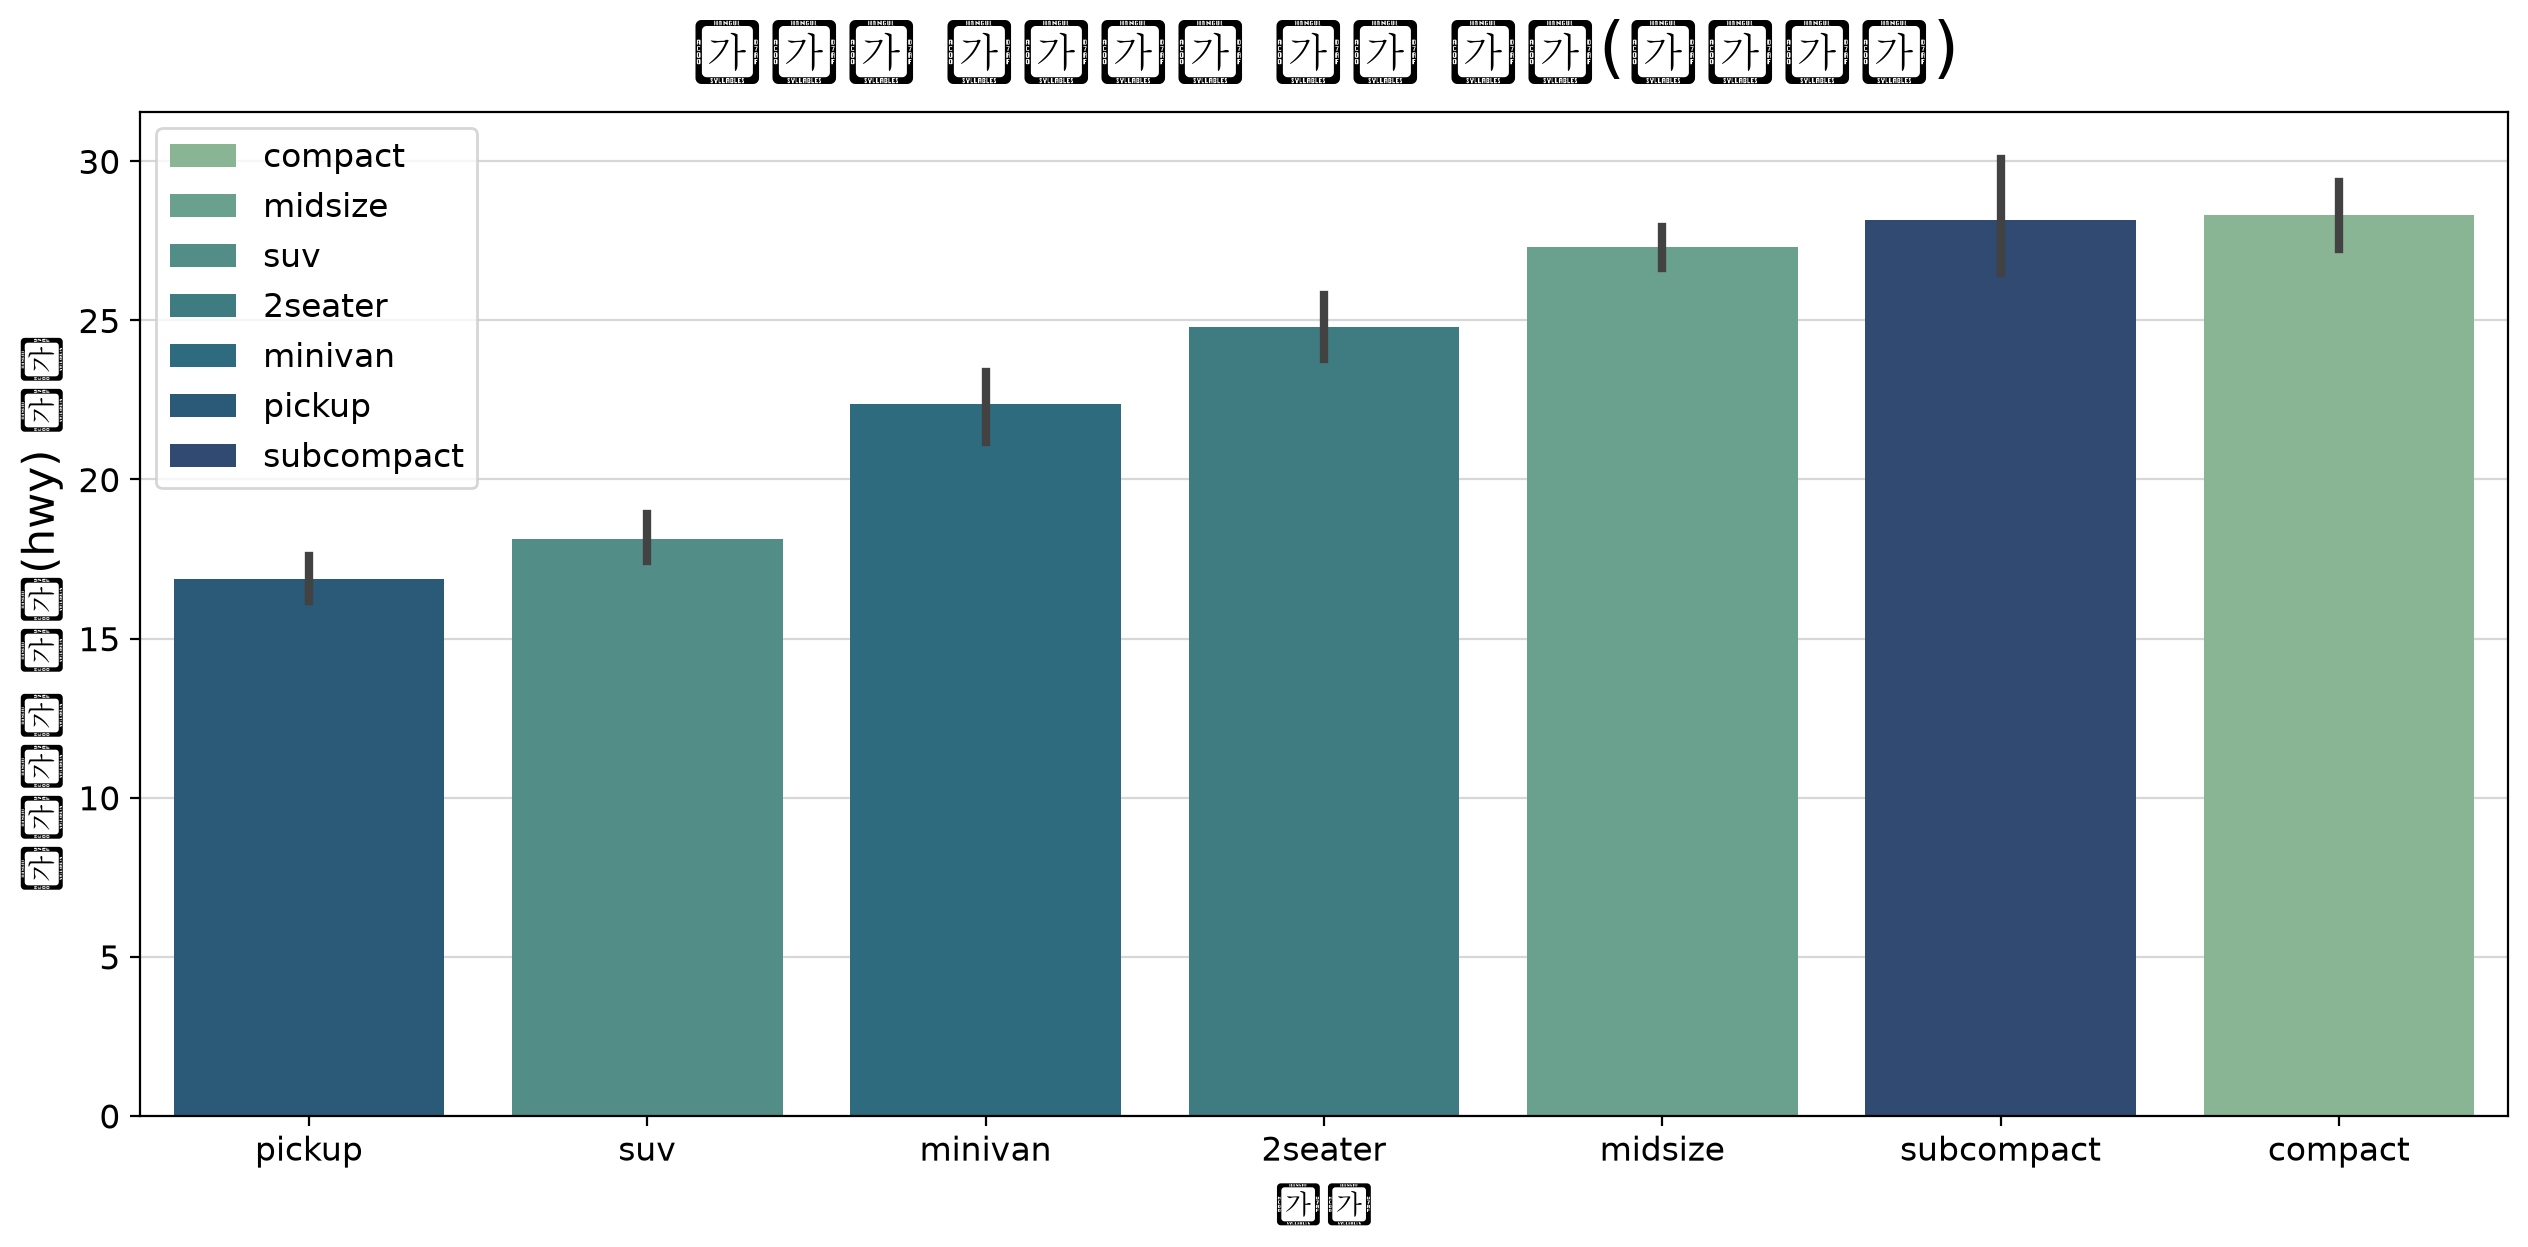

In [15]:
my_plot.barplot(df, x="class", y="hwy", estimator=np.mean,
                order=hwy_mean.index, hue="class", palette="crest",
                title="차종별 고속도로 연비 평균(오름차순)", xlabel="차종", ylabel="고속도로 연비(hwy) 평균")

## 문제 9. 차종(`class`) 중 고속도로 연비(`hwy`) 평균이 가장 높은 종류는?

① compact  ② subcompact  ③ midsize  ④ 2seater

> 💡 **힌트**: 막대그래프 (차종별 hwy 평균, 내림차순 정렬)

## 정답
#### compact 차종이 근소하게 가장 높다. (정답: ① compact)


In [16]:
hwy_mean_desc = df.groupby("class")["hwy"].mean().sort_values(ascending=False)
hwy_mean_desc

class
compact      28.298
subcompact   28.143
midsize      27.293
2seater      24.800
minivan      22.364
suv          18.129
pickup       16.879
Name: hwy, dtype: float64

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 50672

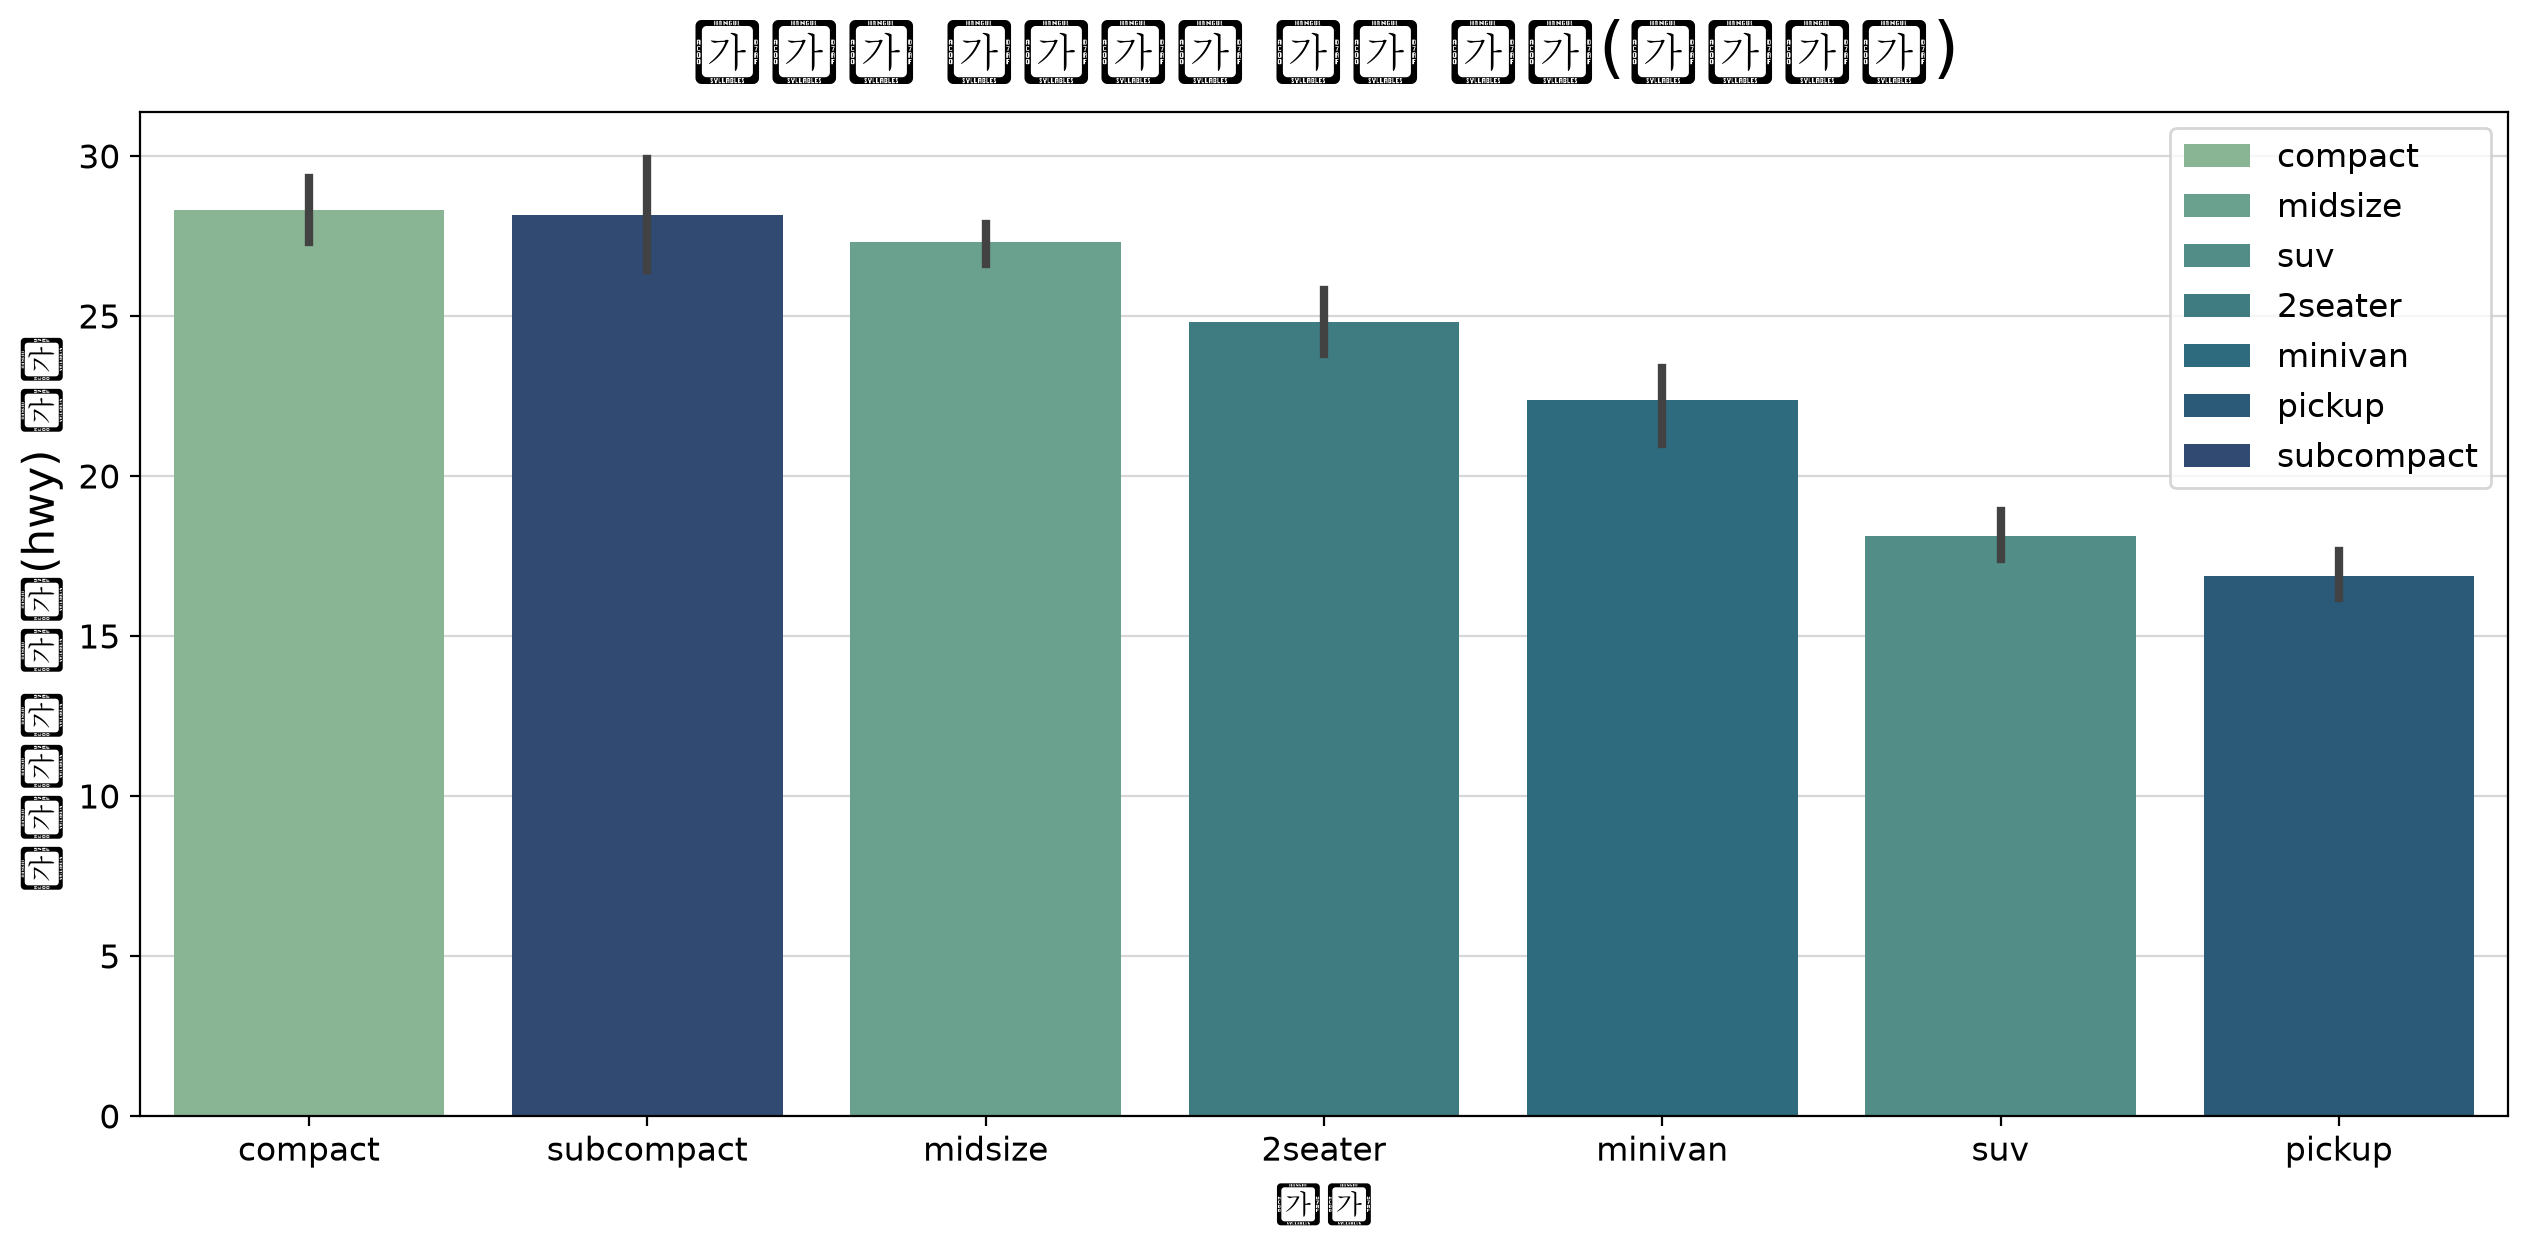

In [17]:
my_plot.barplot(df, x="class", y="hwy", estimator=np.mean,
                order=hwy_mean_desc.index, hue="class", palette="crest",
                title="차종별 고속도로 연비 평균(내림차순)", xlabel="차종", ylabel="고속도로 연비(hwy) 평균")

## 문제 10. 도심 연비(`cty`) 평균이 가장 높은 제조사는?

① volkswagen  ② honda  ③ subaru  ④ hyundai

> 💡 **힌트**: 막대그래프 (제조사별 cty 평균)

## 정답
#### honda 제조사가 도심 연비 평균이 제일 좋다. (정답: ② honda)


In [18]:
cty_by_maker = df.groupby("manufacturer")["cty"].mean().sort_values(ascending=False)
cty_by_maker.head()

manufacturer
honda        24.444
volkswagen   20.926
subaru       19.286
hyundai      18.643
toyota       18.529
Name: cty, dtype: float64

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48708

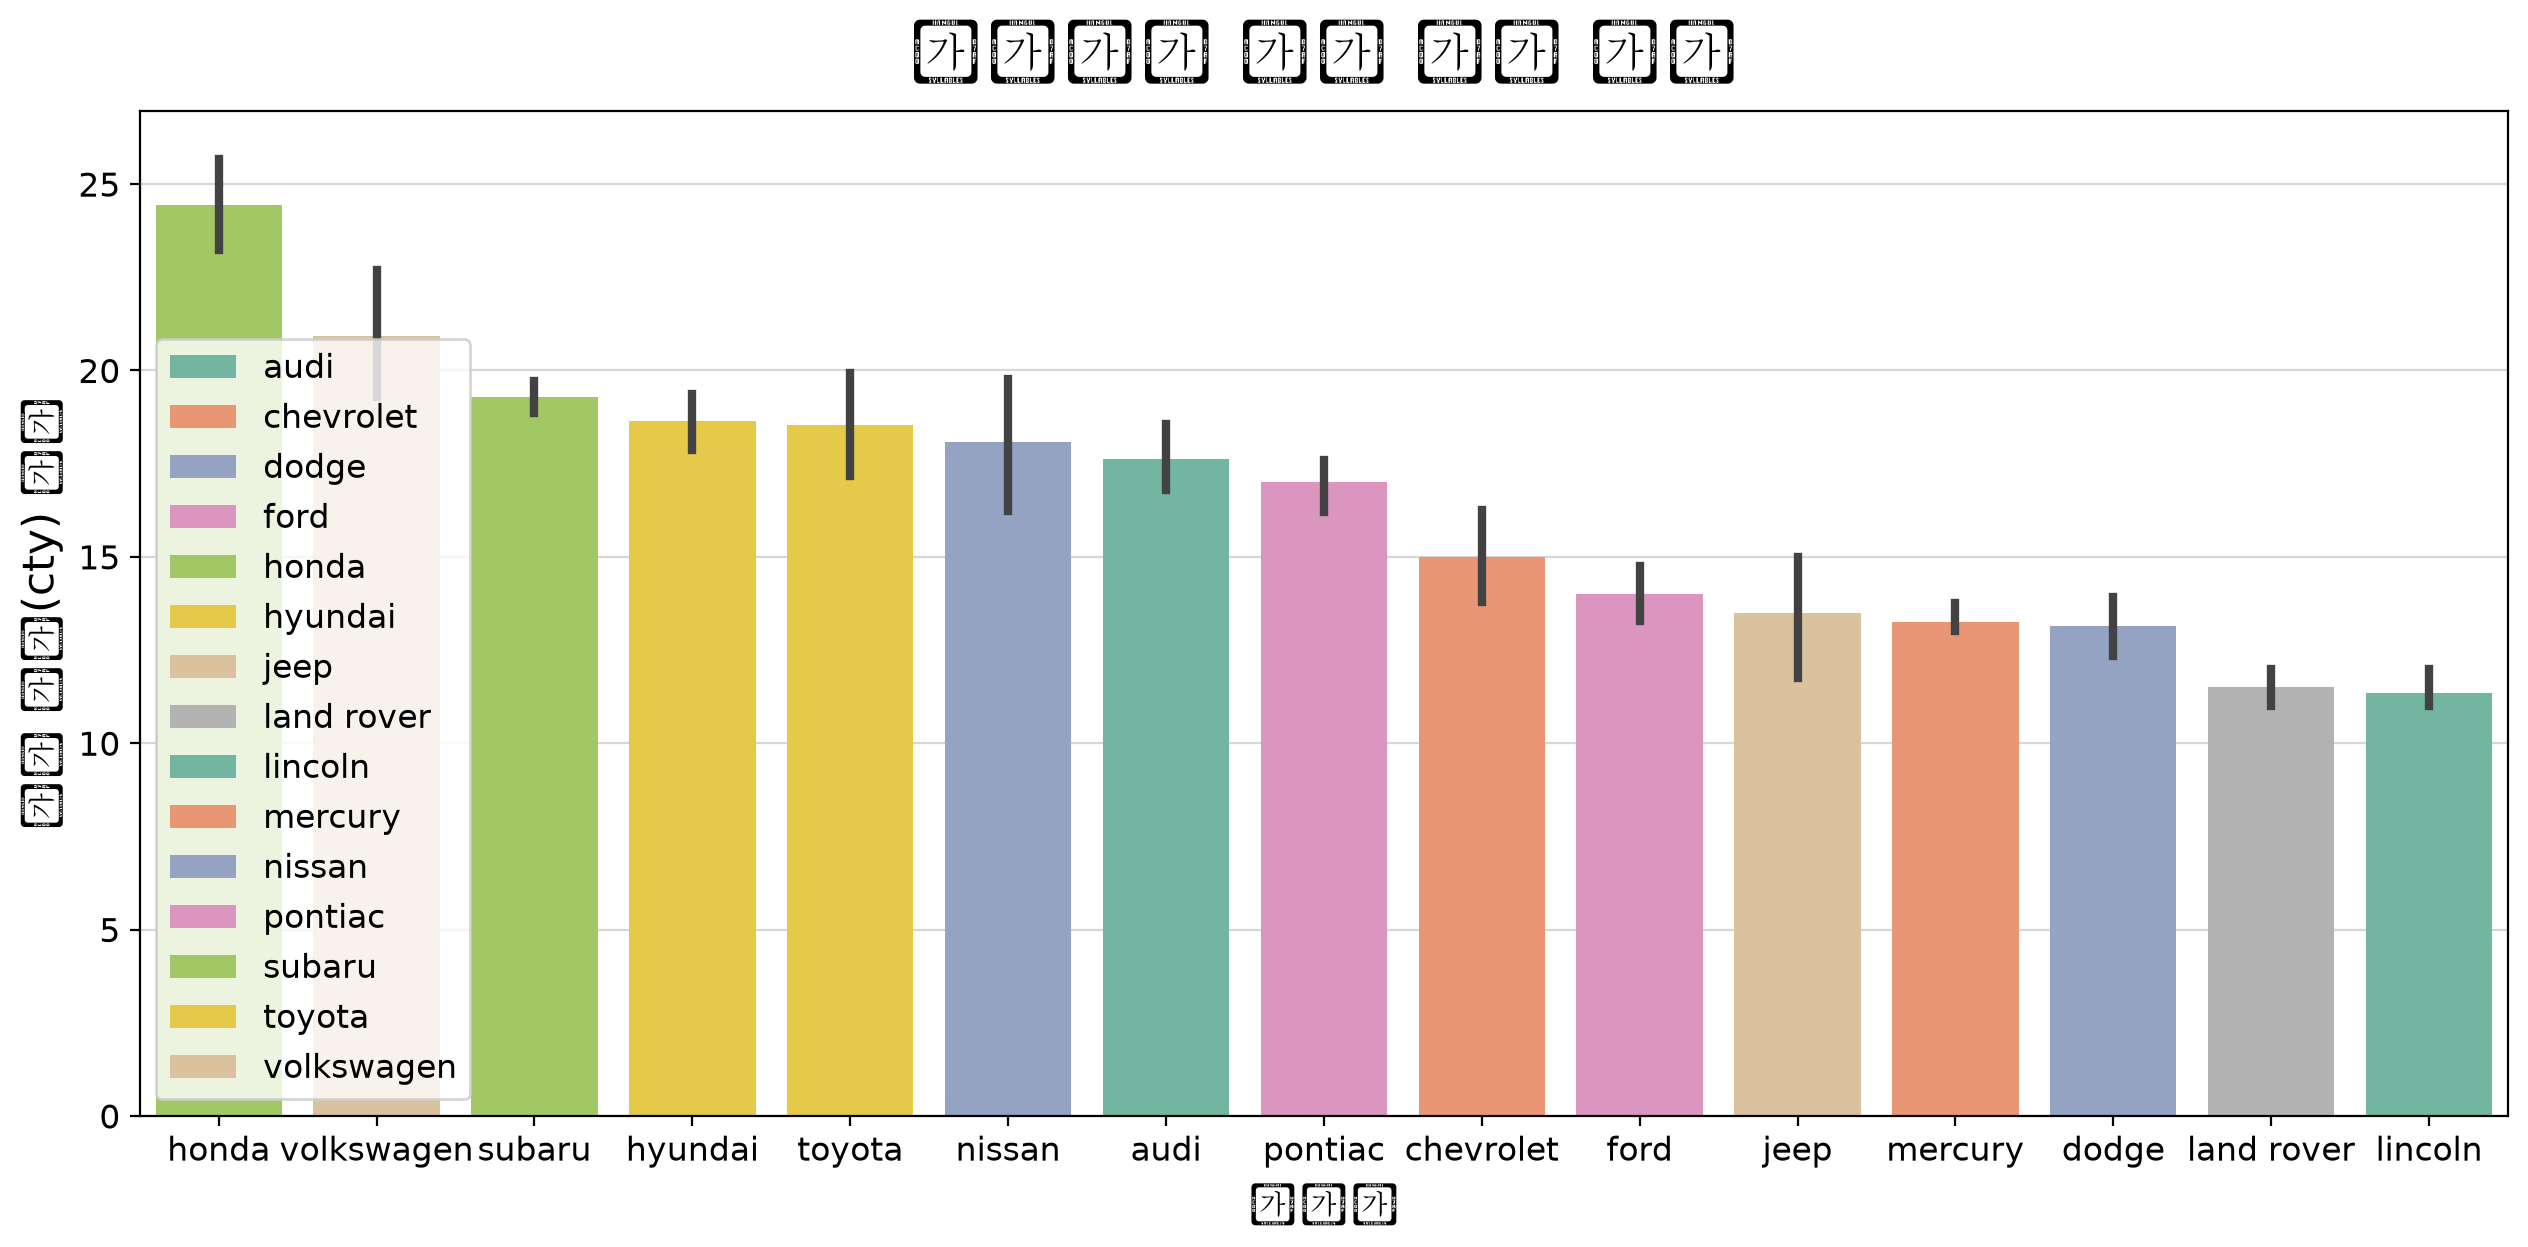

In [19]:
my_plot.barplot(df, x="manufacturer", y="cty", estimator=np.mean,
                order=cty_by_maker.index, hue="manufacturer", palette="Set2",
                title="제조사별 도심 연비 평균", xlabel="제조사", ylabel="도심 연비(cty) 평균")

## 문제 11. 고속도로 연비(`hwy`) 평균이 가장 낮은 제조사는?

① dodge  ② lincoln  ③ land rover  ④ jeep

> 💡 **힌트**: 막대그래프 (제조사별 hwy 평균)

## 정답
#### land rover 제조사가 고속도로 연비 평균이 제일 안 좋다. (정답: ③ land rover)


In [20]:
hwy_by_maker = df.groupby("manufacturer")["hwy"].mean().sort_values()
hwy_by_maker.head()

manufacturer
land rover   16.500
lincoln      17.000
jeep         17.625
dodge        17.946
mercury      18.000
Name: hwy, dtype: float64

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47196 (

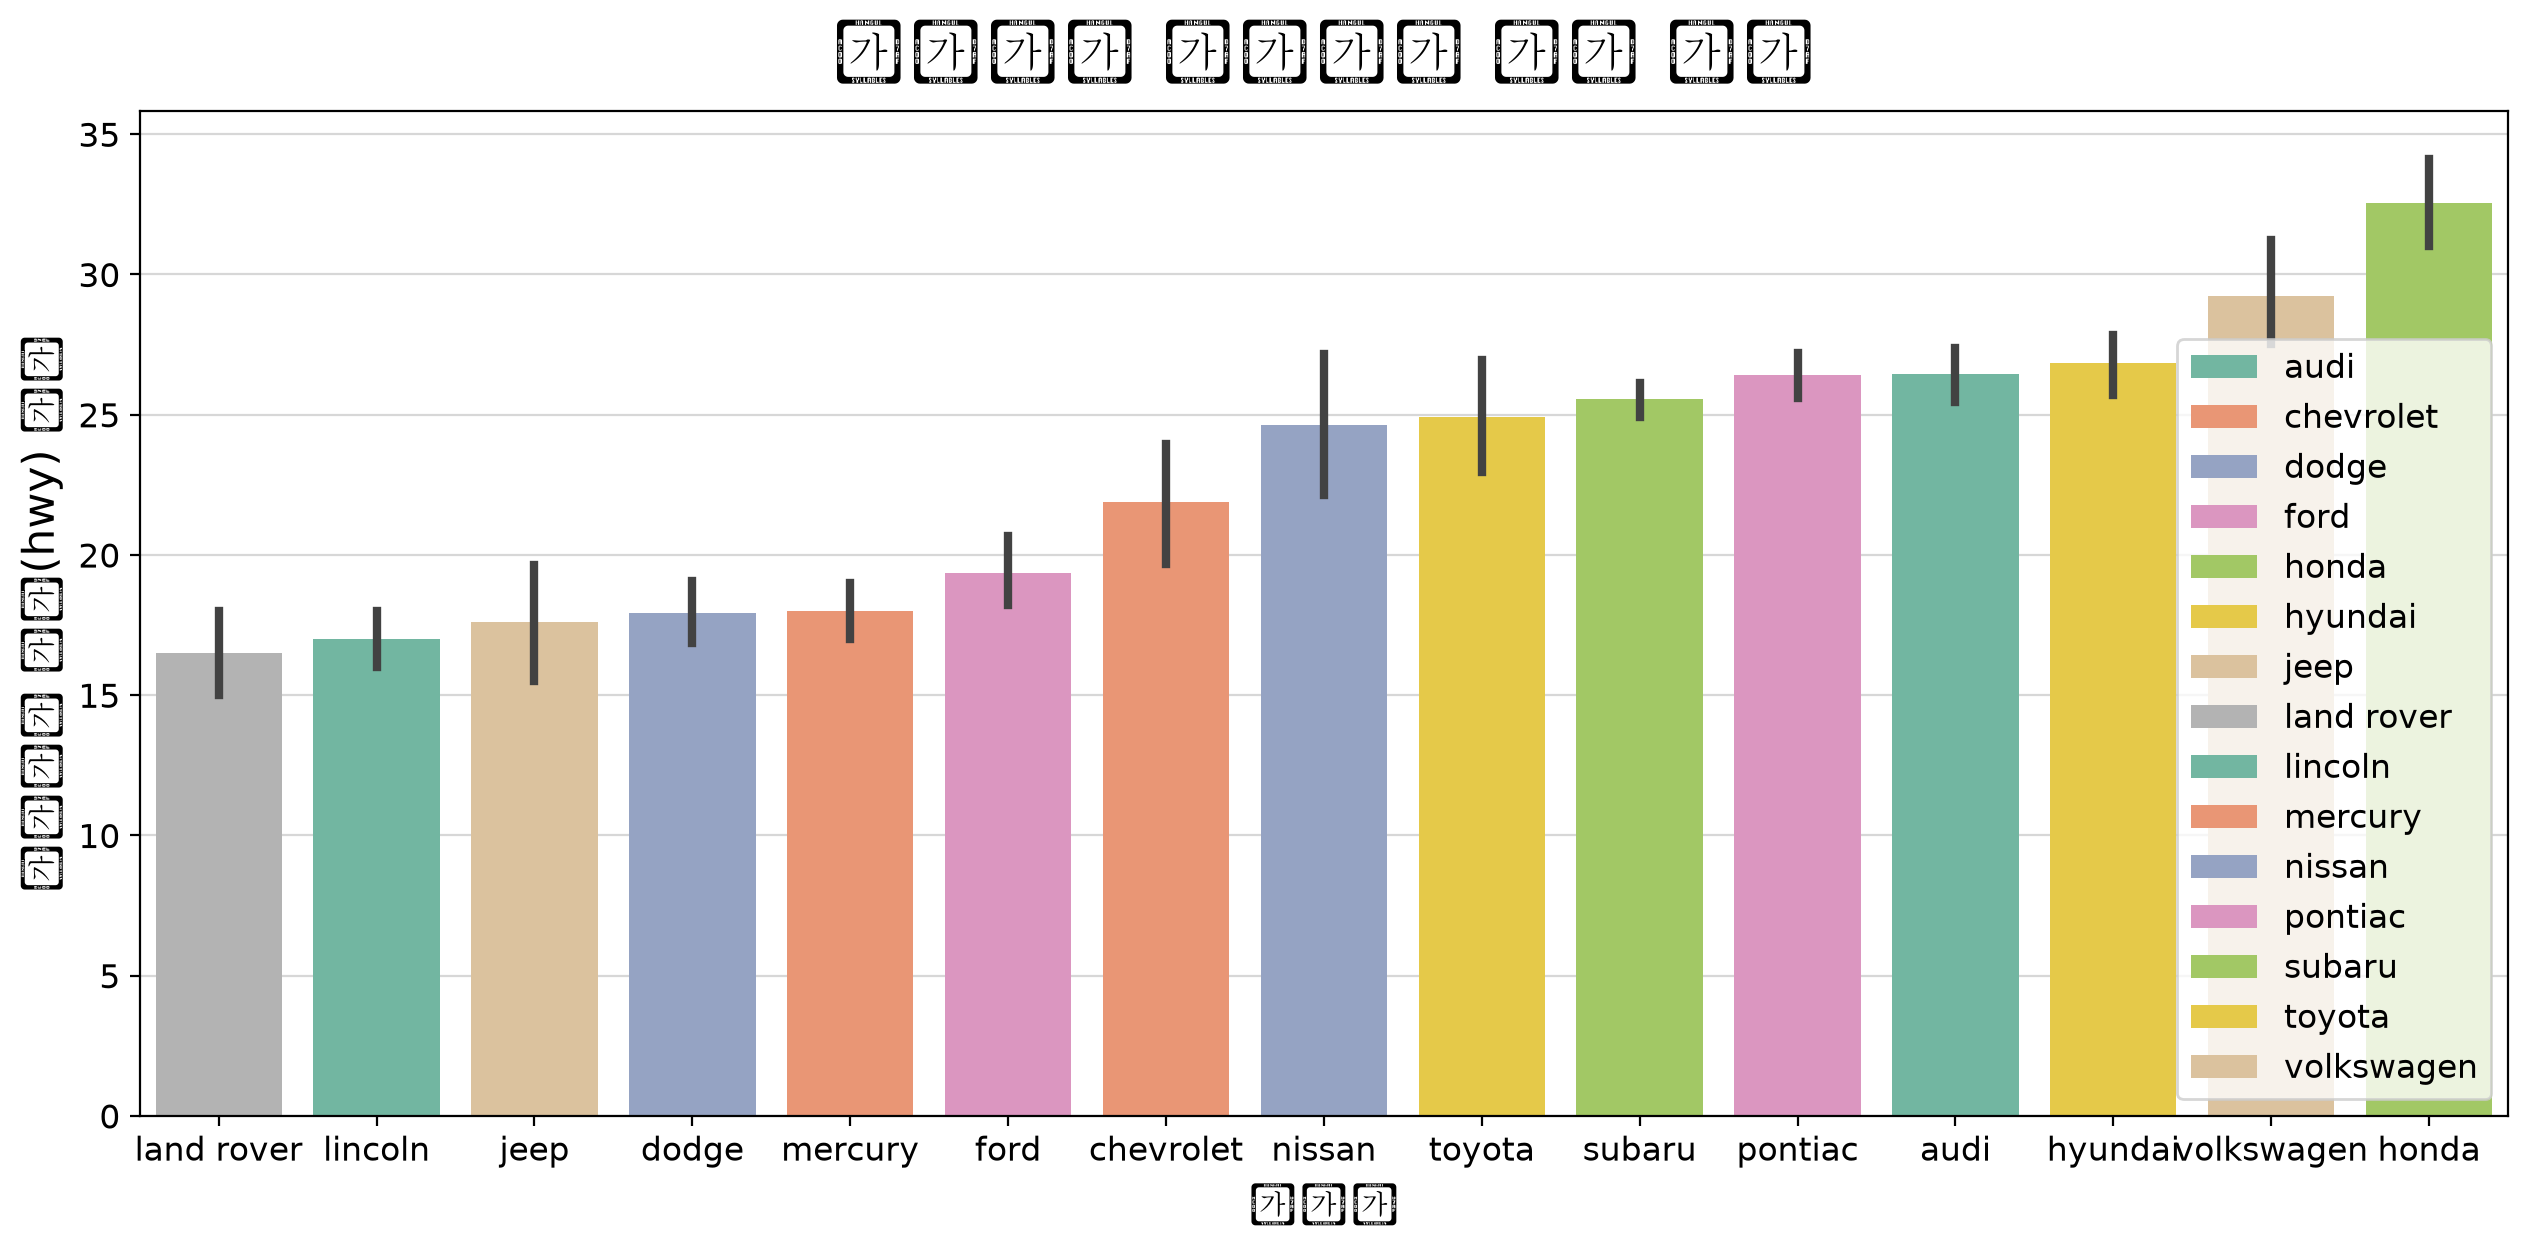

In [21]:
my_plot.barplot(df, x="manufacturer", y="hwy", estimator=np.mean,
                order=hwy_by_maker.index, hue="manufacturer", palette="Set2",
                title="제조사별 고속도로 연비 평균", xlabel="제조사", ylabel="고속도로 연비(hwy) 평균")

## 문제 12. 변속기 종류(자동 vs 수동)에 따른 연비 비교로 옳은 것은?

① 자동이 수동보다 연비가 높다  ② 수동이 자동보다 연비가 높다  ③ 차이가 없다  ④ 도심은 자동, 고속도로는 수동이 높다

> 💡 **힌트**: 막대그래프 (`trans`를 auto/manual로 묶은 뒤 cty·hwy 평균)

## 정답
#### 도심, 고속도로 둘 다 평균 연비는 수동 쪽이 더 좋다. (정답: ② 수동이 자동보다 연비가 높다)


In [22]:
df2 = df.copy()
df2.loc[df2["trans"].str.contains("auto"), "trans_type"] = "자동"
df2.loc[df2["trans"].str.contains("manual"), "trans_type"] = "수동"
df2[["trans", "trans_type"]].drop_duplicates()

,trans,trans_type
id,,
1,auto(l5),자동
2,manual(m5),수동
3,manual(m6),수동
4,auto(av),자동
11,auto(s6),자동
19,auto(l4),자동
38,auto(l3),자동
47,auto(l6),자동
154,auto(s5),자동


C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 50

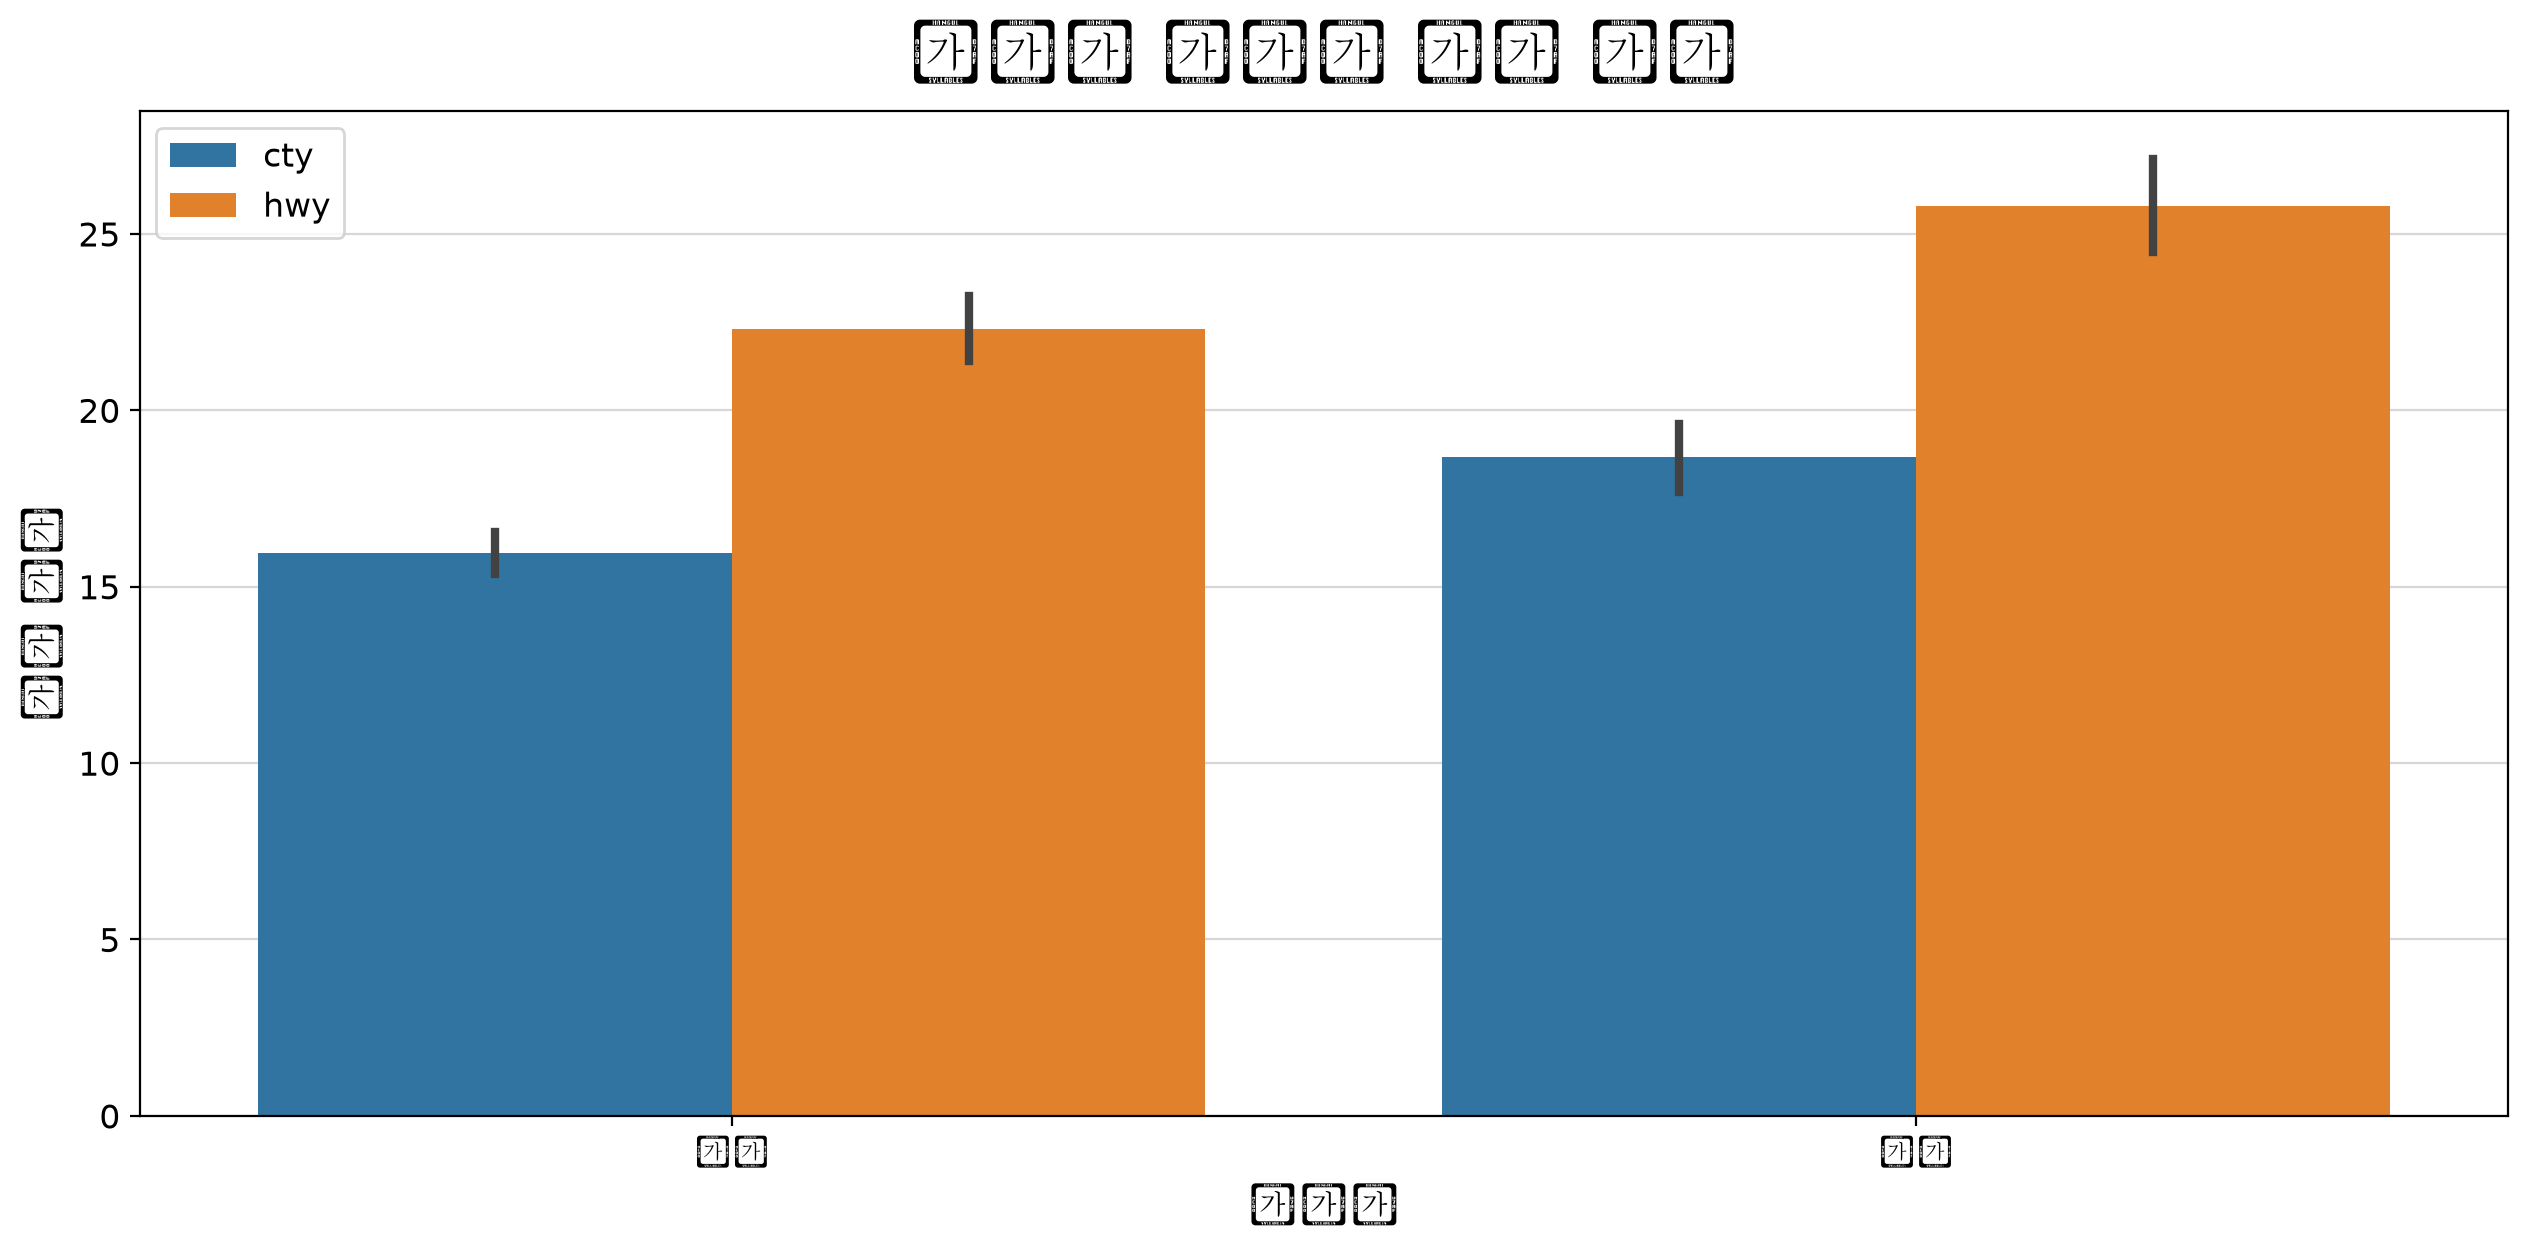

In [23]:
long_df = df2.melt(id_vars="trans_type", value_vars=["cty", "hwy"],
                   var_name="연비종류", value_name="연비")
my_plot.barplot(long_df, x="trans_type", y="연비", hue="연비종류",
                title="변속기 종류별 평균 연비", xlabel="변속기", ylabel="연비 평균")

## 문제 13. 가장 많이 사용된 연료(`fl`) 종류는?

① p (프리미엄)  ② r (레귤러)  ③ e (에탄올)  ④ d (디젤)

> 💡 **힌트**: 막대그래프 또는 원그래프 (연료별 빈도)

## 정답
#### 레귤러(r) 연료가 압도적으로 많이 쓰였다. (정답: ② r (레귤러))


In [24]:
df2 = df.copy()
df2["fl"] = df2["fl"].map({"p": "프리미엄", "r": "레귤러", "e": "에탄올", "d": "디젤", "c": "CNG"})
fl_cnt = df2["fl"].value_counts()
fl_cnt

fl
레귤러     168
프리미엄     52
에탄올       8
디젤        5
CNG       1
Name: count, dtype: int64

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44516 (\N{HANGUL SYLLABLE GYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 54532 (\N{HANGUL SYLLABLE PEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 5062

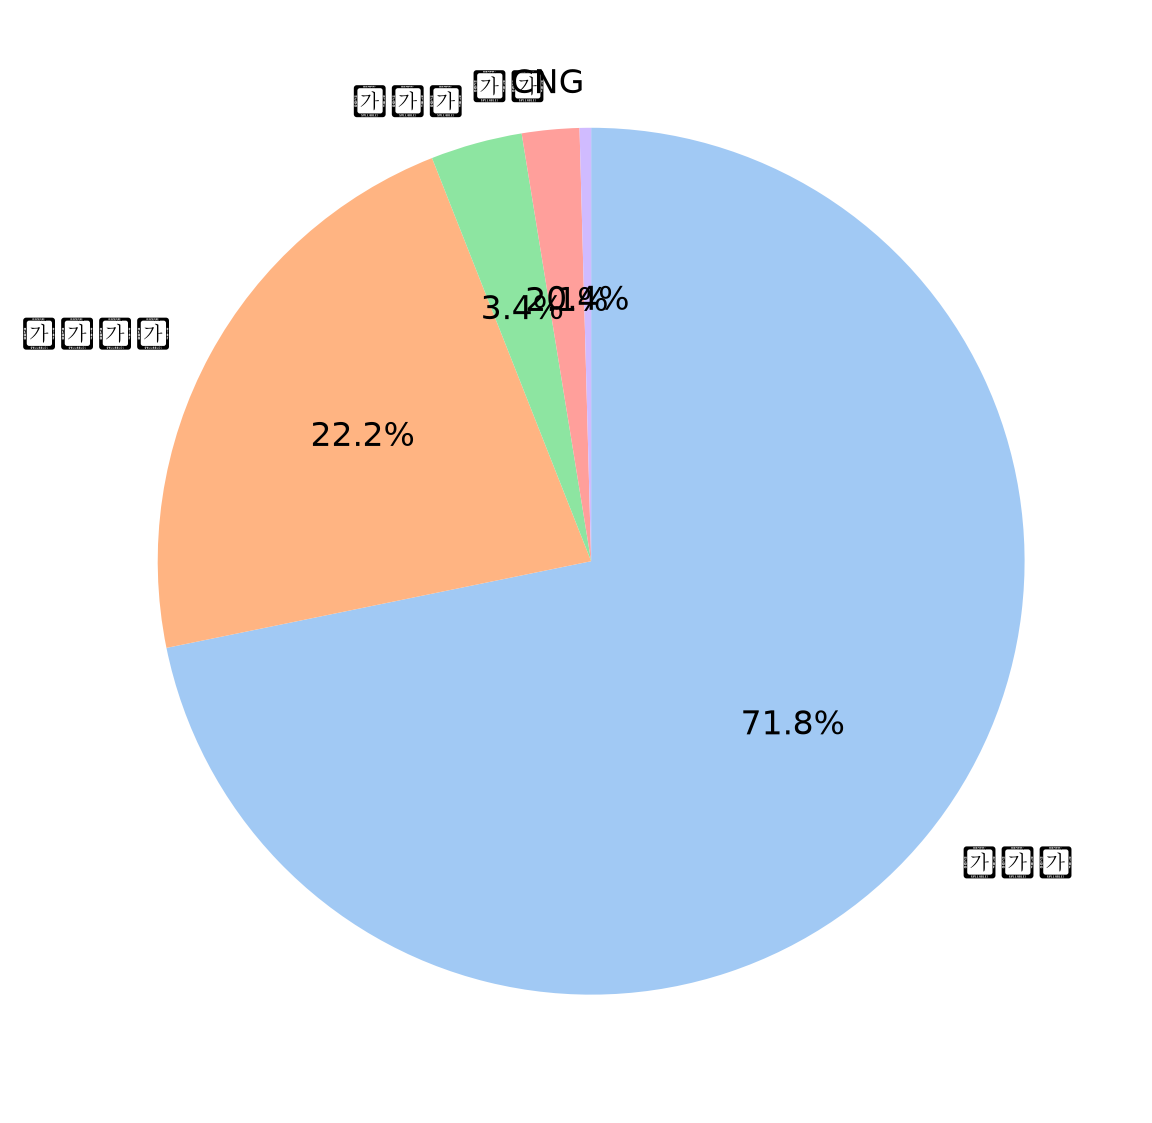

In [25]:
my_plot.pieplot(x=fl_cnt.values, labels=fl_cnt.index, palette="pastel", width=600, height=600)

## 문제 14. 1999년과 2008년의 평균 고속도로 연비(`hwy`)를 비교하면?

① 2008년이 크게 향상되었다  ② 1999년이 더 높다  ③ 거의 차이가 없다  ④ 2008년이 절반 수준이다

> 💡 **힌트**: 막대그래프 (연식별 hwy 평균)

## 정답
#### 1999년과 2008년의 hwy 평균은 큰 차이가 없다. (정답: ③ 거의 차이가 없다)


C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 4870

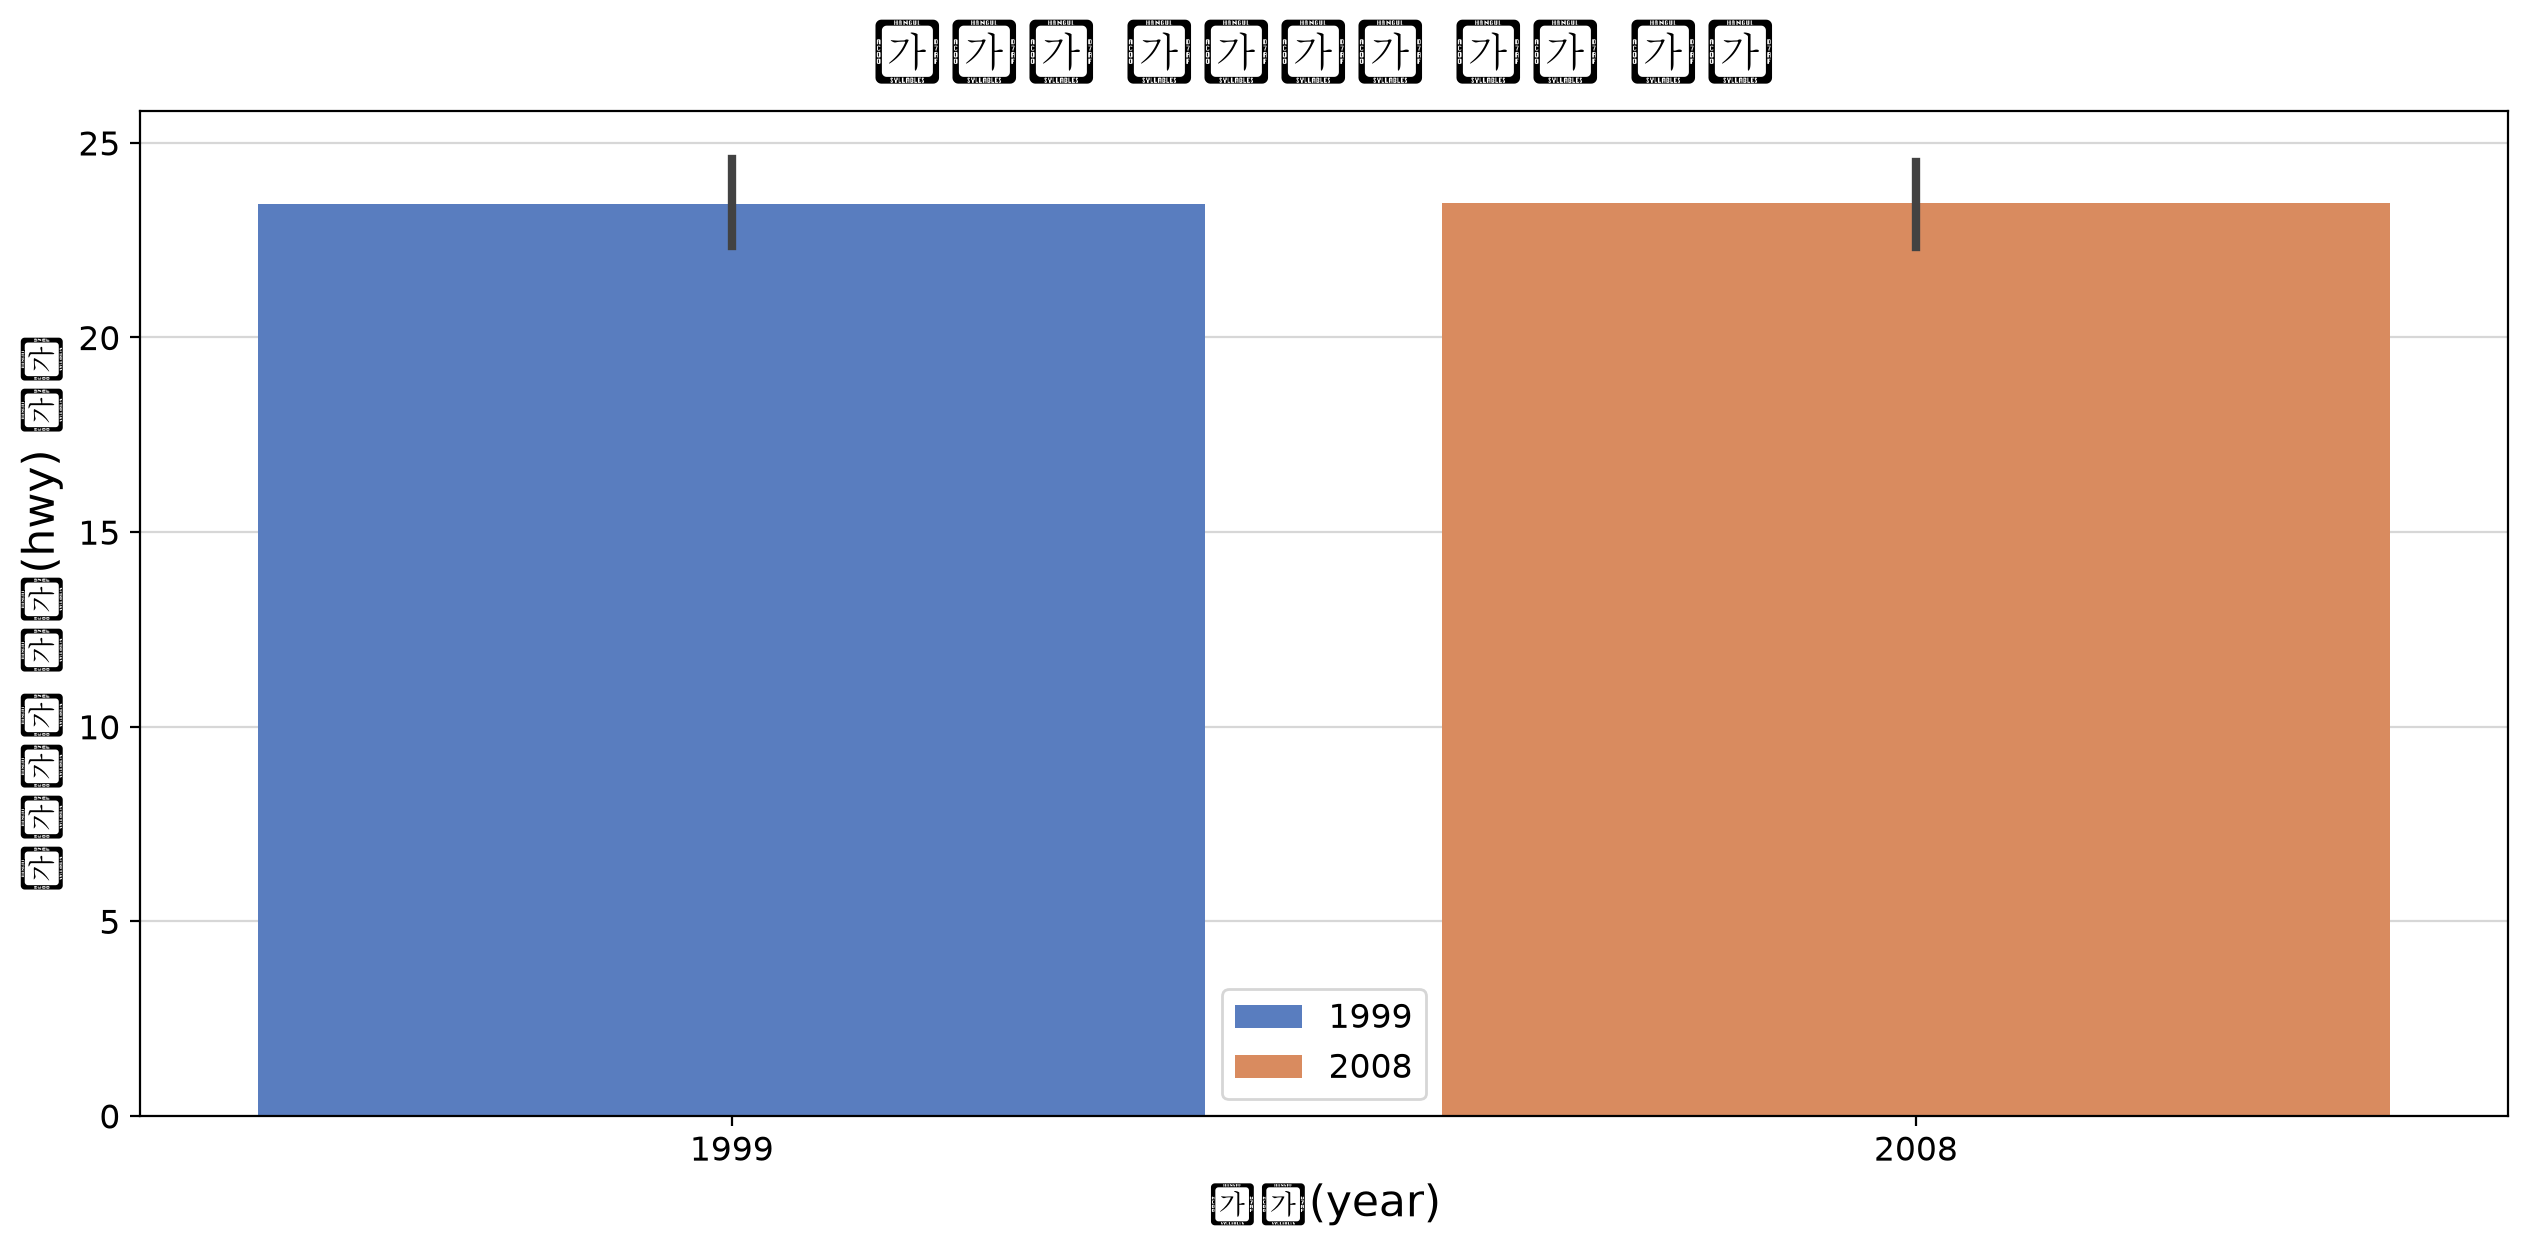

In [26]:
my_plot.barplot(df, x="year", y="hwy", estimator=np.mean,
                hue="year", palette="muted",
                title="연식별 고속도로 연비 평균", xlabel="연식(year)", ylabel="고속도로 연비(hwy) 평균")

## 문제 15. SUV 차종에는 존재하지 않는 구동방식은?

① 4륜구동  ② 후륜구동  ③ 전륜구동  ④ 모두 존재한다

> 💡 **힌트**: 막대그래프 (차종 SUV로 필터 후 구동방식별 빈도) 또는 교차표 시각화

## 정답
#### SUV에는 전륜구동이 존재하지 않는다. (정답: ③ 전륜구동)


In [27]:
suv = df[df["class"] == "suv"]
suv["drv"].value_counts()

drv
4륜구동    51
후륜구동    11
Name: count, dtype: int64

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47452 (\N{HANGUL SYLLABLE RYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 5

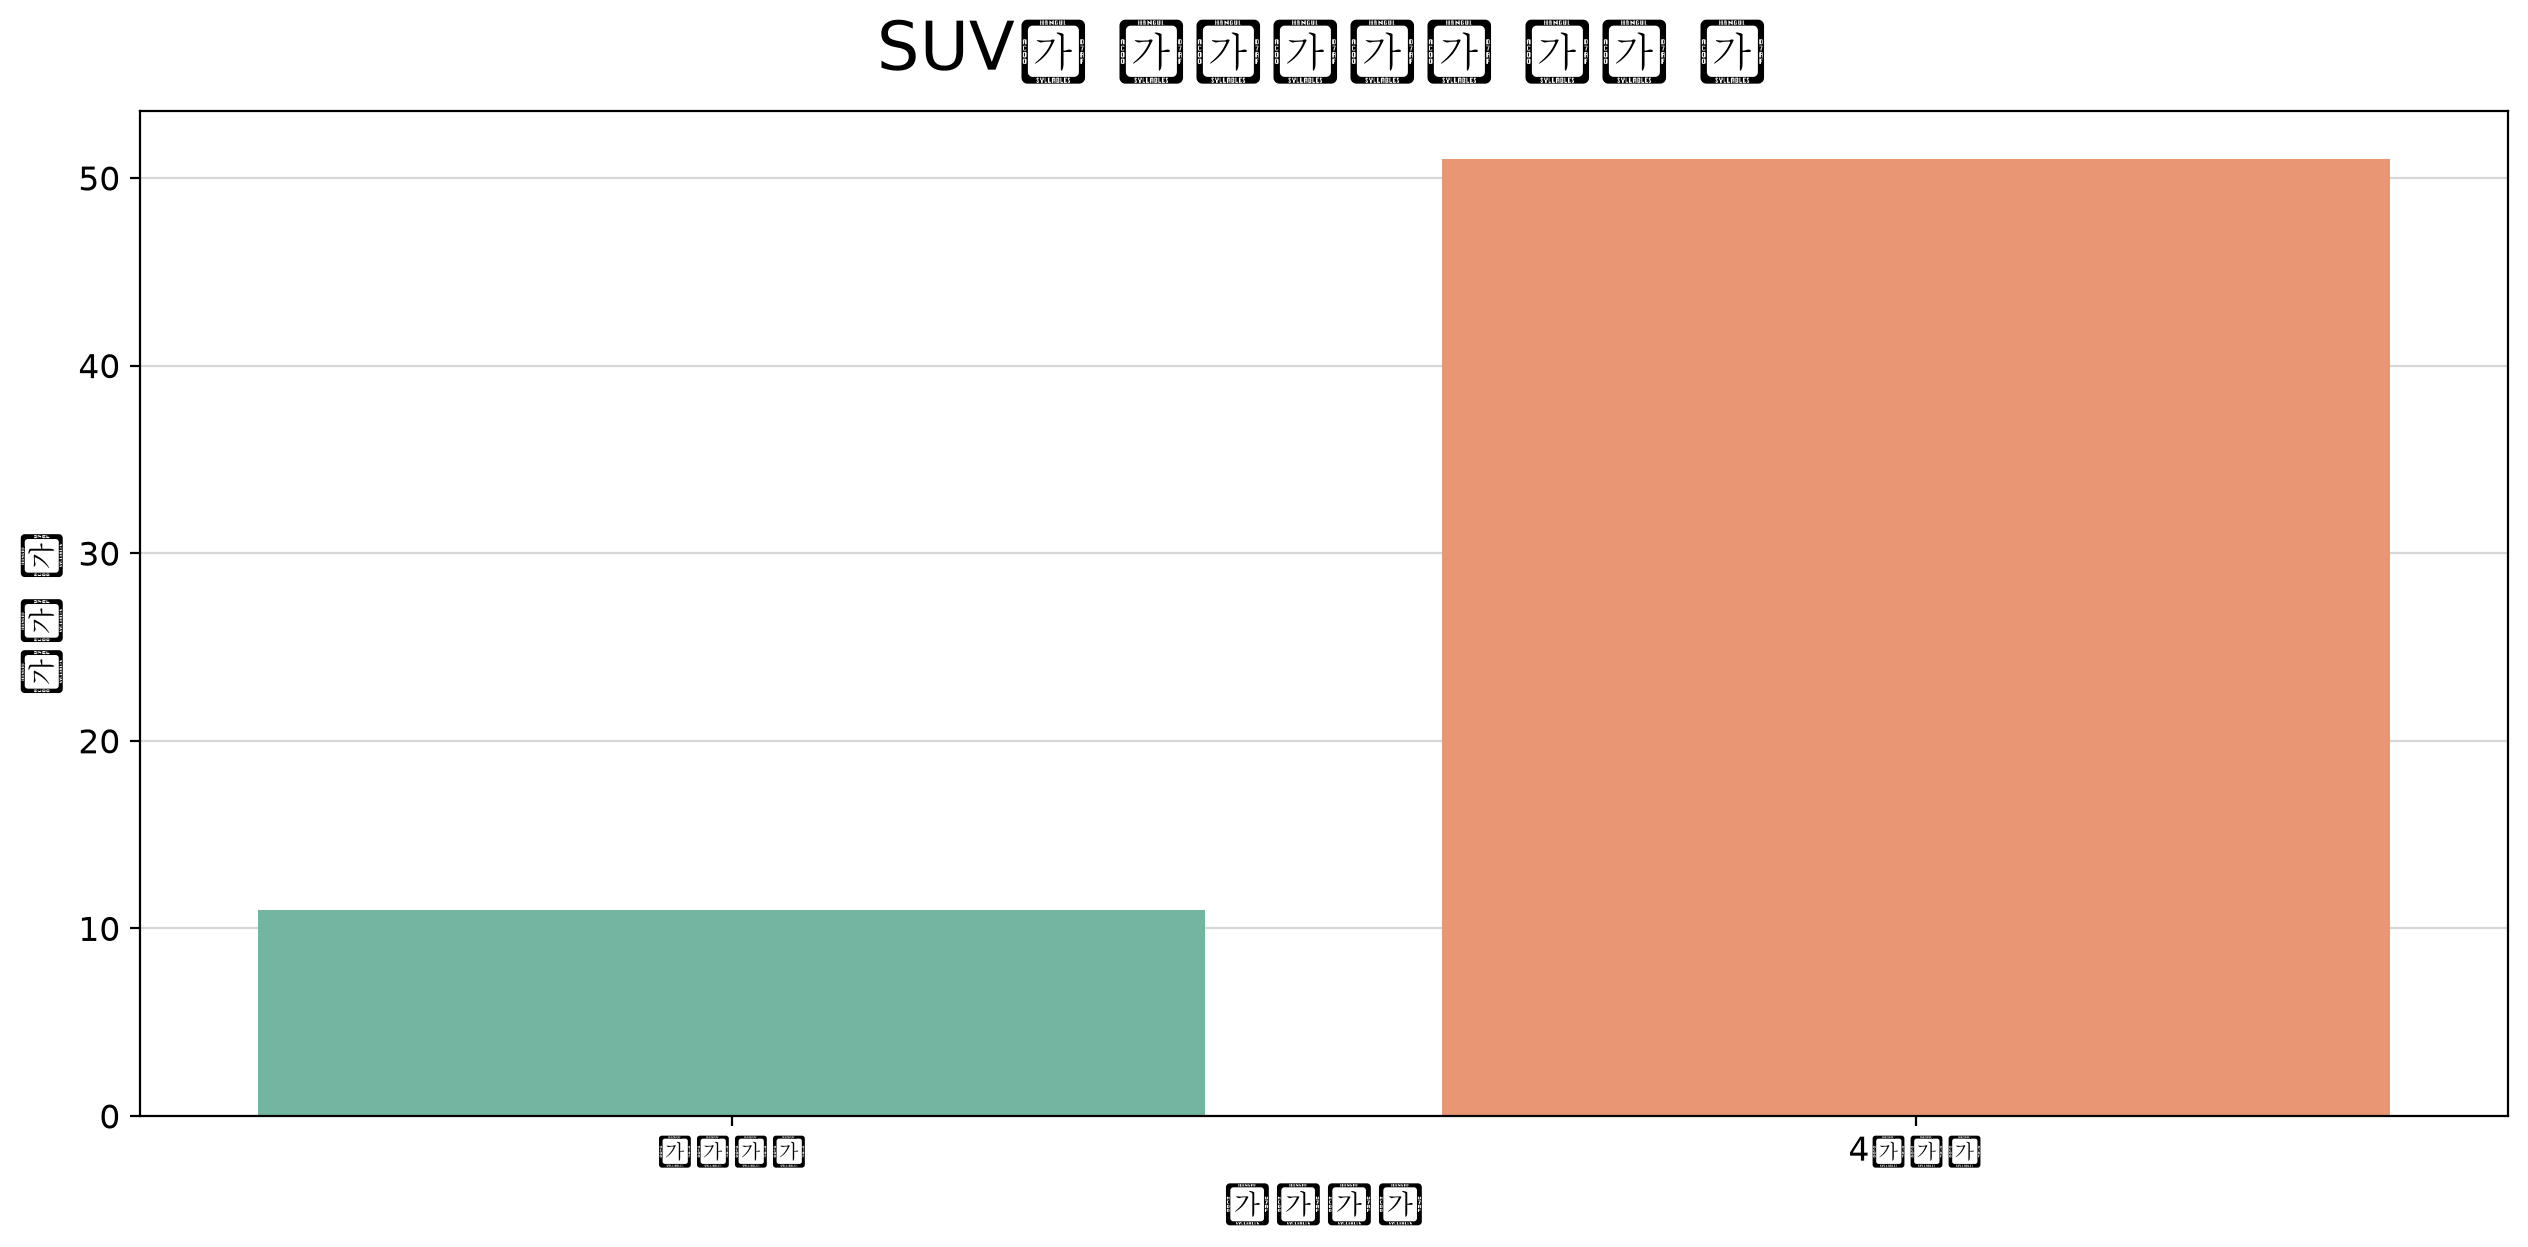

In [28]:
my_plot.countplot(suv, x="drv", hue="drv", palette="Set2",
                  title="SUV의 구동방식별 차량 수", xlabel="구동방식", ylabel="차량 수")

## 문제 16. 픽업(pickup) 차종의 구동방식은?

① 모두 4륜구동  ② 모두 전륜구동  ③ 4륜·후륜 혼합  ④ 전륜·4륜 혼합

> 💡 **힌트**: 막대그래프 (차종 pickup으로 필터 후 구동방식별 빈도)

## 정답
#### pickup은 전부 4륜구동이다. (정답: ① 모두 4륜구동)


In [29]:
pickup = df[df["class"] == "pickup"]
pickup["drv"].unique()

<ArrowStringArray>
['4륜구동']
Length: 1, dtype: str

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47452 (\N{HANGUL SYLLABLE RYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 4

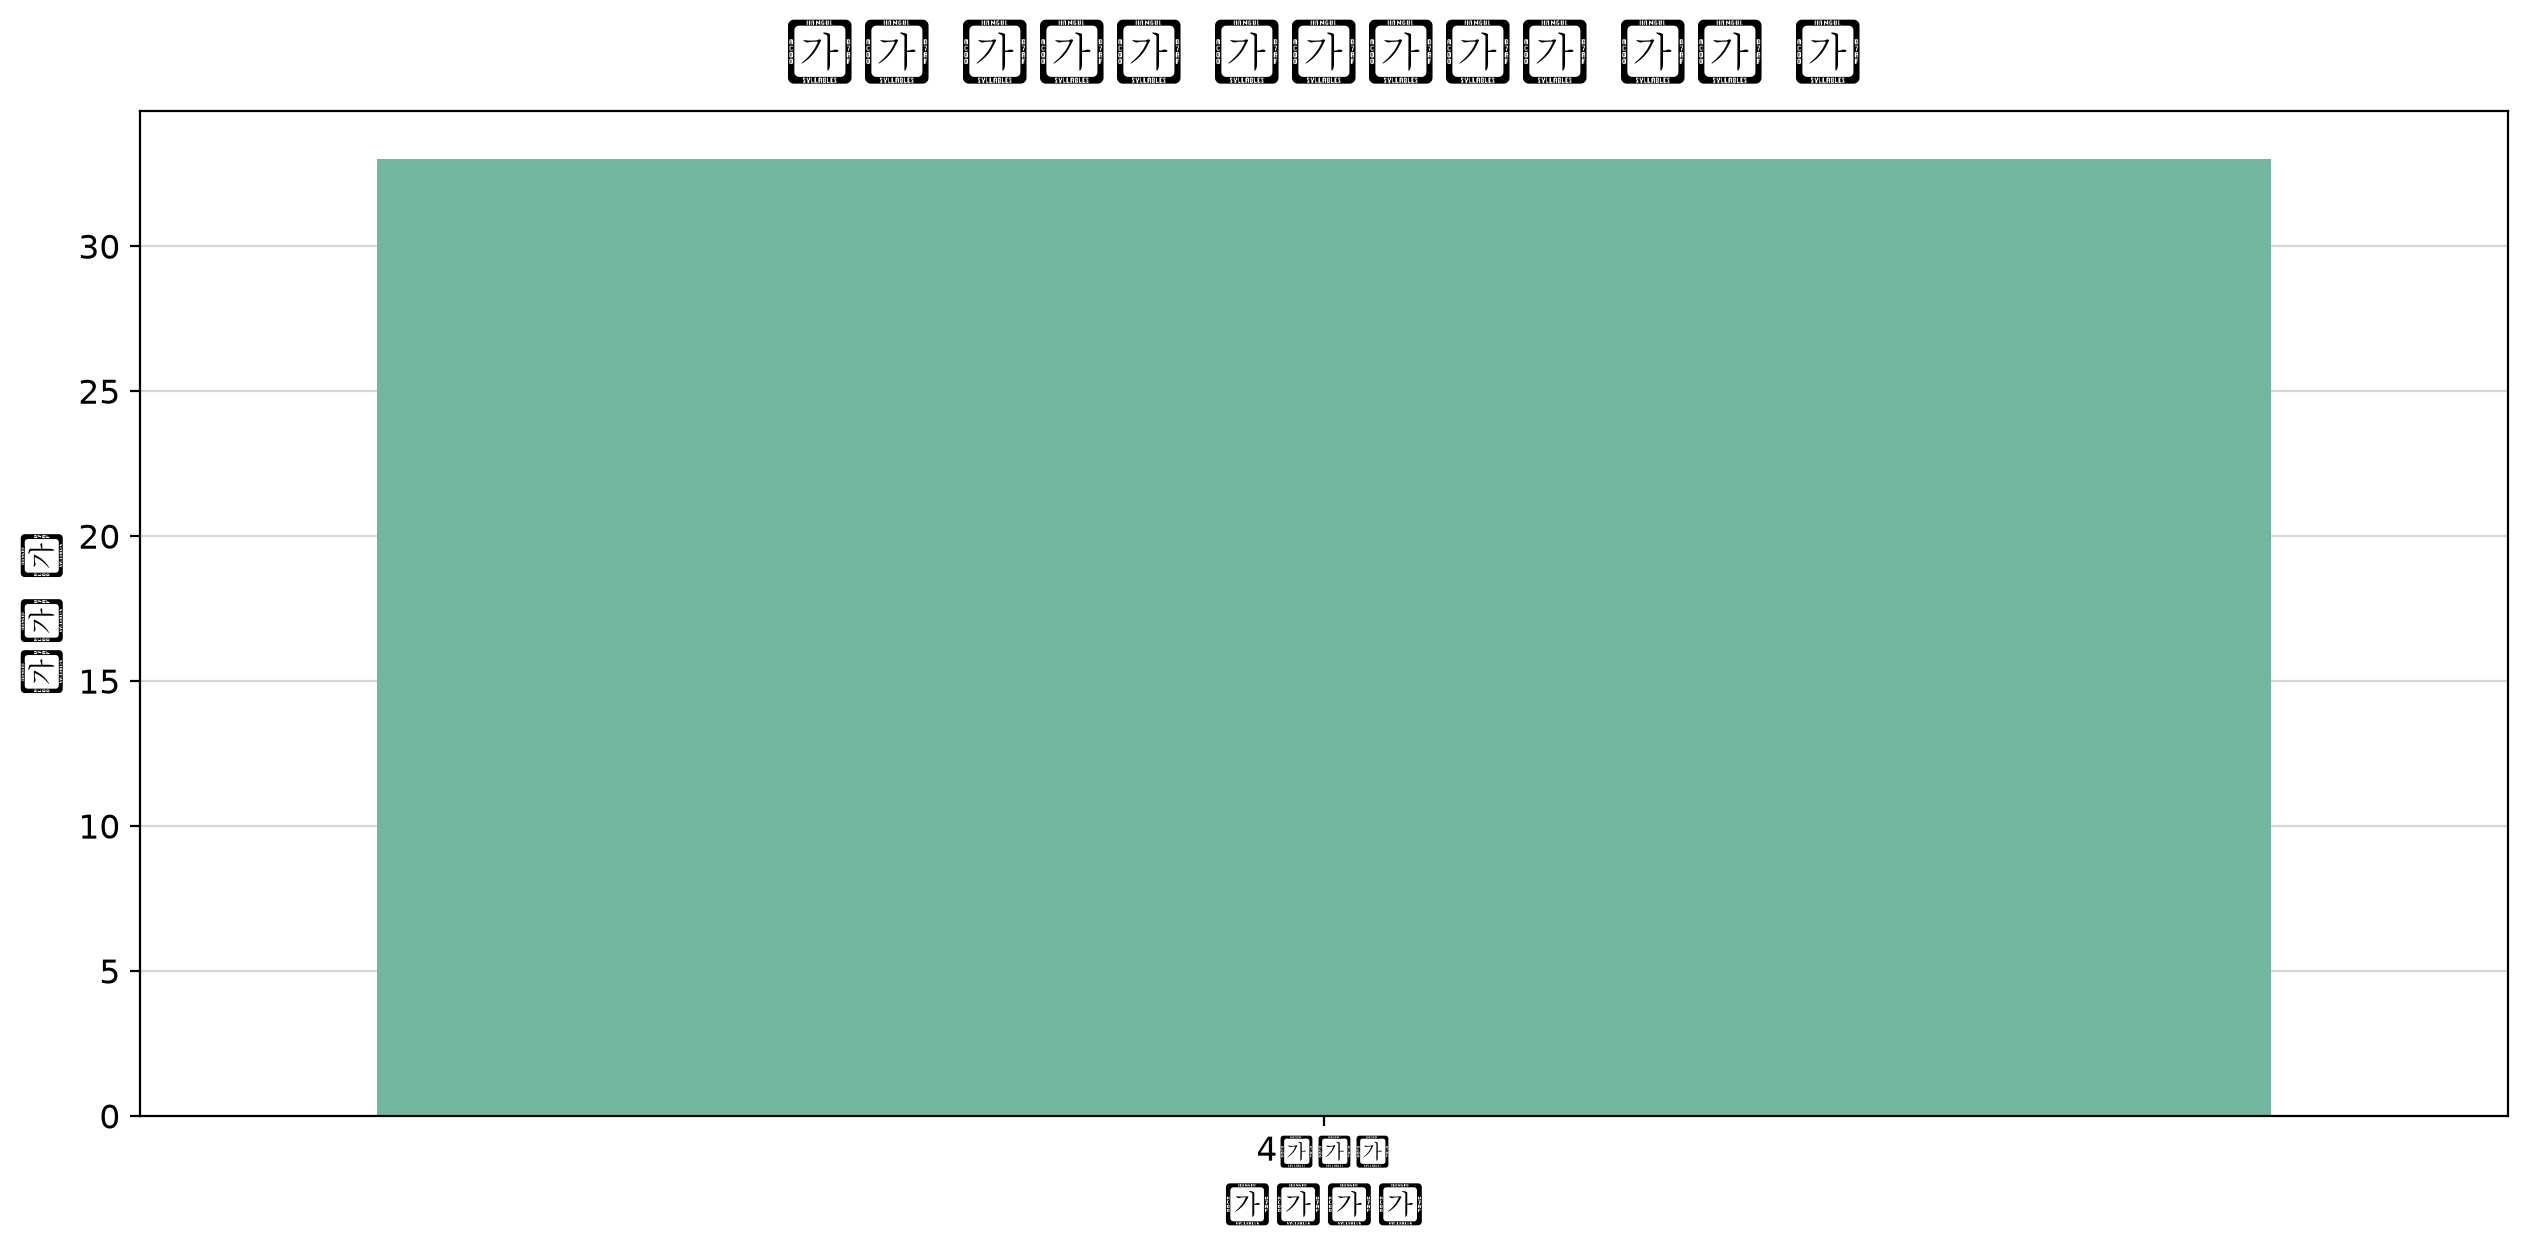

In [30]:
my_plot.countplot(pickup, x="drv", hue="drv", palette="Set2",
                  title="픽업 차종의 구동방식별 차량 수", xlabel="구동방식", ylabel="차량 수")

## 문제 17. 평균연비 `(cty + hwy) / 2`가 전체 평균보다 높은(합격, Pass) 차량의 비율에 가장 가까운 값은?

① 약 25%  ② 약 47%  ③ 약 53%  ④ 약 75%

> 💡 **힌트**: 원그래프 (Pass/Fail 비율)

## 정답
#### 전체 평균연비 기준 Pass 비율은 약 53% 수준이다. (정답: ③ 약 53%)


In [31]:
df3 = df.copy()
df3["평균연비"] = (df3["cty"] + df3["hwy"]) / 2
df3["합격여부"] = np.where(df3["평균연비"] >= df3["평균연비"].mean(), "Pass", "Fail")
df3["합격여부"].value_counts(normalize=True)

합격여부
Pass   0.526
Fail   0.474
Name: proportion, dtype: float64

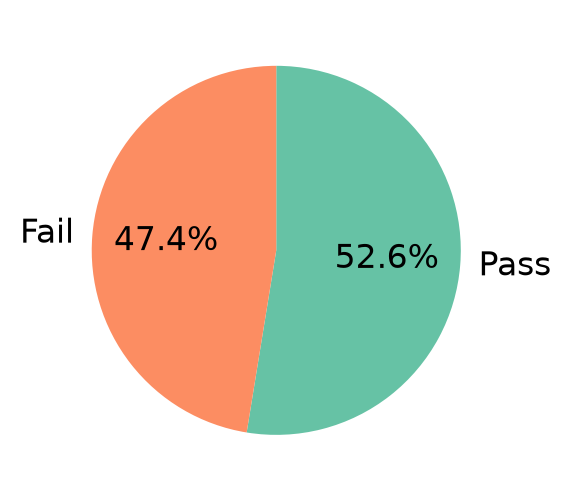

In [32]:
grade_cnt = df3["합격여부"].value_counts()
my_plot.pieplot(x=grade_cnt.values, labels=grade_cnt.index, palette="Set2", width=300, height=300)

## 문제 18. 배기량(`displ`) 분포의 중앙값(median)에 가장 가까운 값은?

① 2.4  ② 3.3  ③ 3.5  ④ 4.6

> 💡 **힌트**: 히스토그램 또는 박스플롯 (displ 분포)

## 정답
#### displ 중앙값은 3.3 부근이다. (정답: ② 3.3)


In [33]:
df["displ"].describe()

count   234.000
mean      3.472
std       1.292
min       1.600
25%       2.400
50%       3.300
75%       4.600
max       7.000
Name: displ, dtype: float64

C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ITWILL\workspace\helpers\my_plot.py:69: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ITWILL\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io

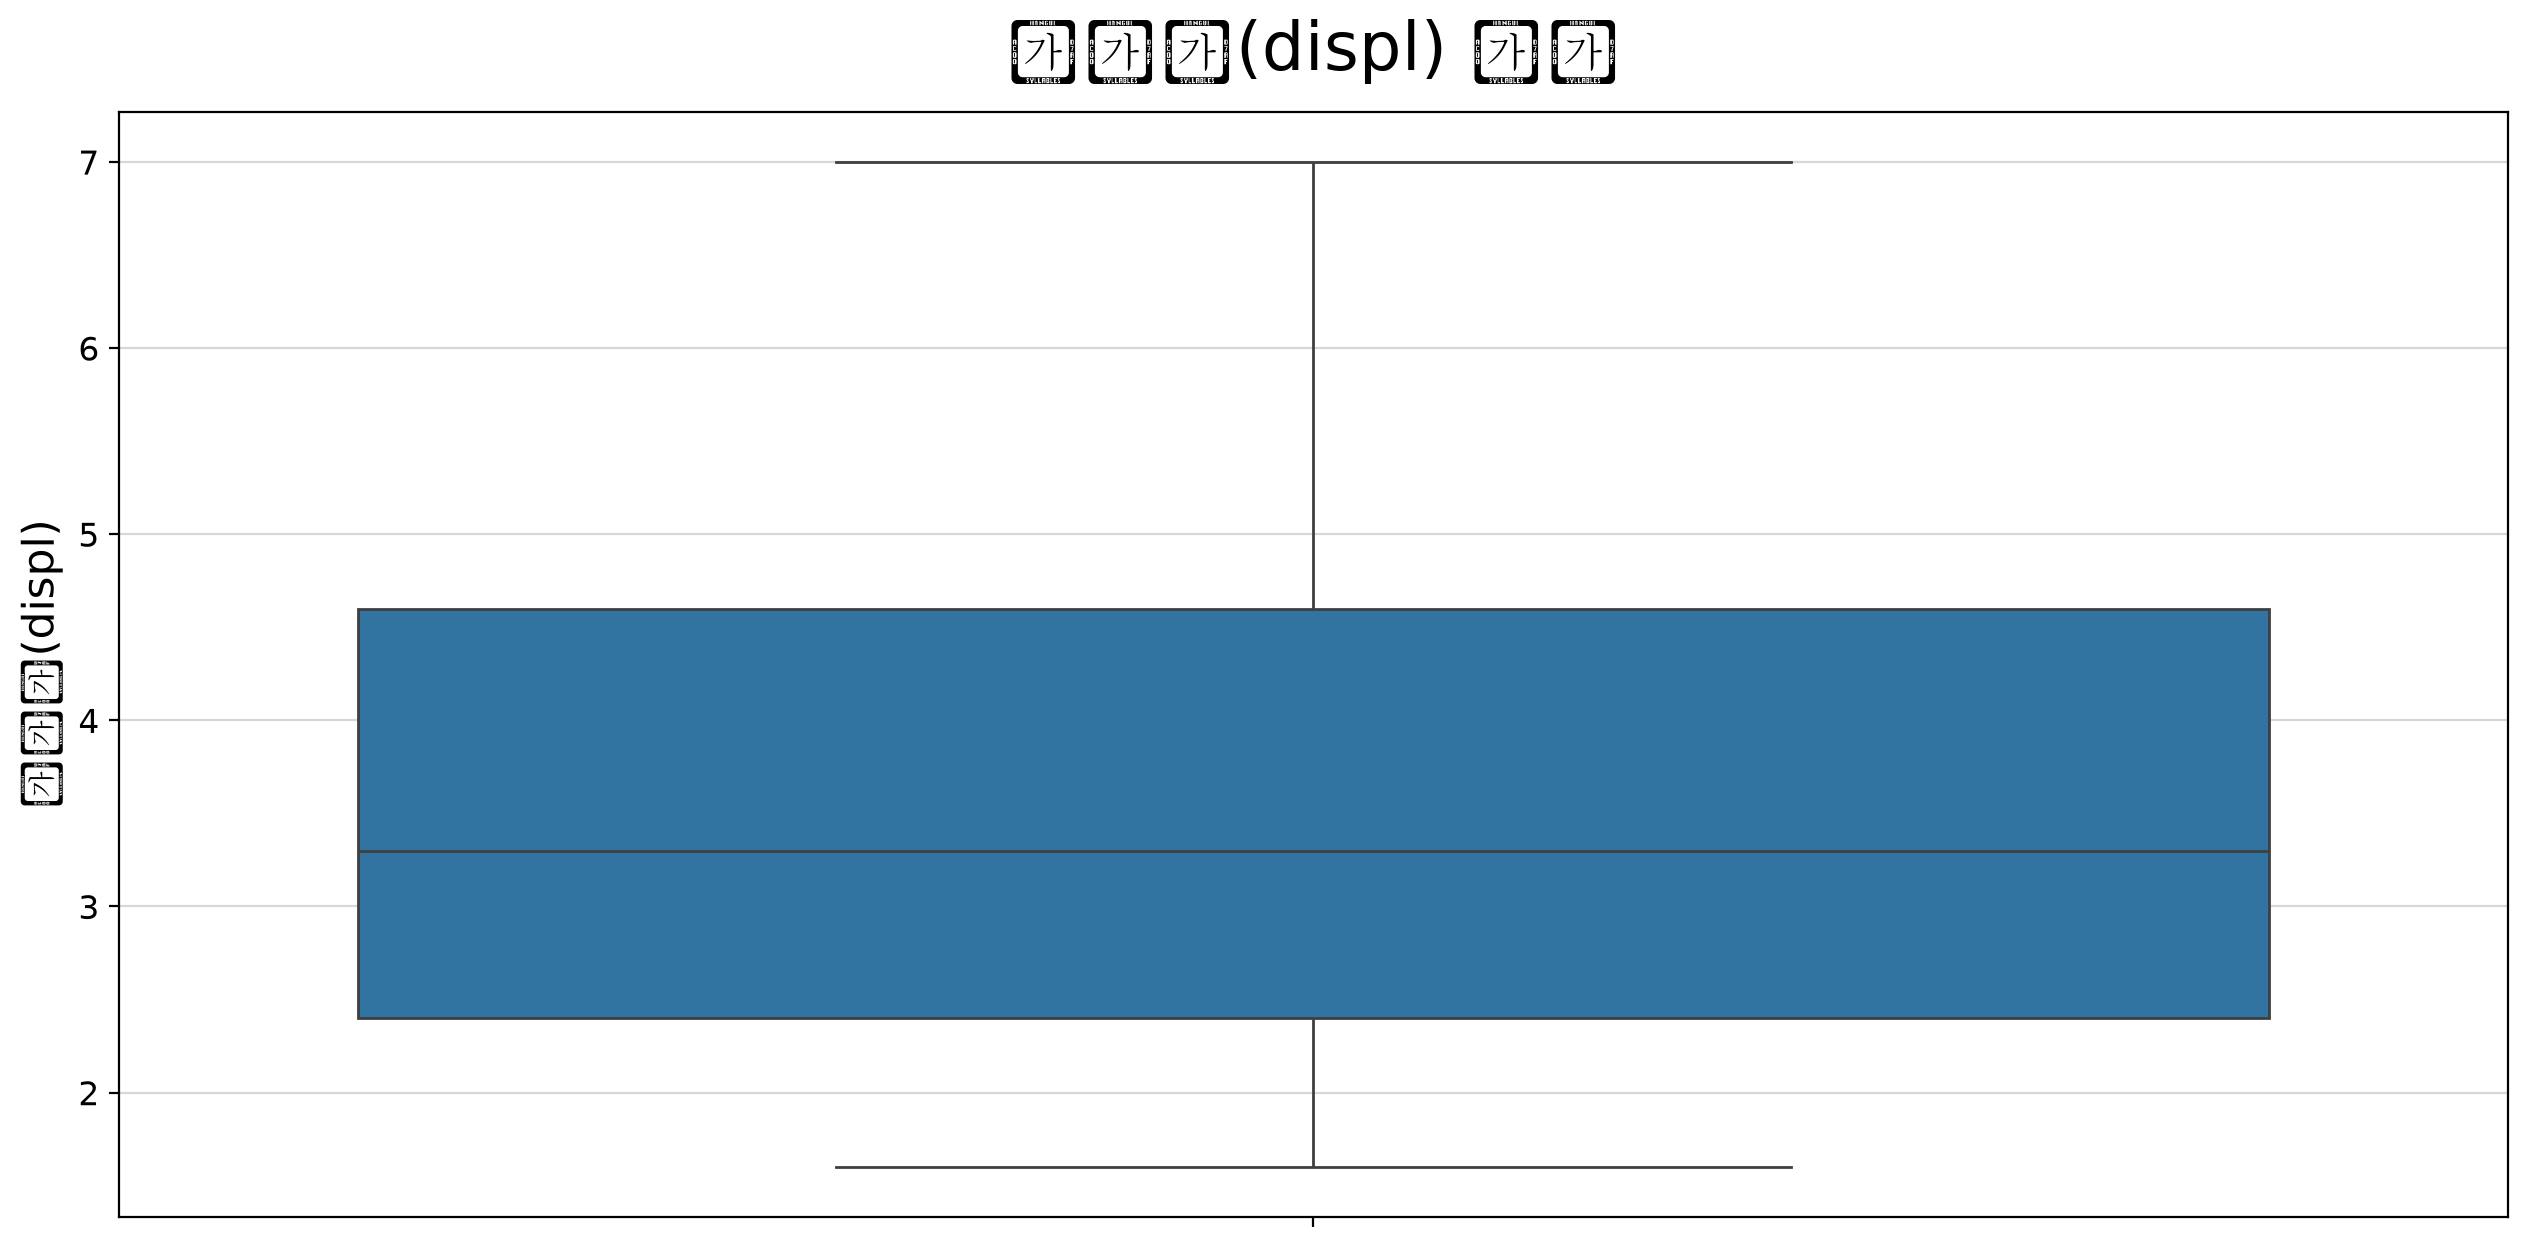

In [34]:
my_plot.boxplot(df, y="displ", title="배기량(displ) 분포", ylabel="배기량(displ)")